In [3]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os
import glob


def _normalize_asset_name(name):
    name = str(name).strip().upper()
    if name.endswith("_H") or name.endswith("_E"):
        return name[:-2]
    return name

In [4]:
def clean_refinitiv_file(path, asset_name):
	raw = pd.read_excel(path)

	header_idx = raw.index[
		raw.apply(
			lambda r: r.astype(str).str.contains("Exchange Date", case=False, na=False)
		).any(axis=1)
	][0]

	cols = raw.loc[header_idx].tolist()
	df = raw.loc[header_idx + 1 :].copy()
	df.columns = cols

	df = df[["Exchange Date", "Close"]].dropna()
	df["Exchange Date"] = pd.to_datetime(df["Exchange Date"])
	df = df.sort_values("Exchange Date")

	prices = df.set_index("Exchange Date")["Close"].astype(float)
	prices.name = asset_name
	return prices

In [5]:
def load_historical_prices(folder_path):
    """Load and clean all stock files in folder_path using clean_refinitiv_file."""
    price_series = []

    for file_path in sorted(glob.glob(os.path.join(folder_path, "*"))):
        if not os.path.isfile(file_path):
            continue

        asset_name = _normalize_asset_name(os.path.splitext(os.path.basename(file_path))[0])
        try:
            series = clean_refinitiv_file(file_path, asset_name)
            price_series.append(series)
        except Exception as err:
            print(f"Skipping {file_path}: {err}")

    if not price_series:
        raise ValueError(f"No valid historical price files found in {folder_path}")

    prices_df = pd.concat(price_series, axis=1).sort_index()
    return prices_df

In [6]:
from pathlib import Path
import re

def extract_overall_esg_2024_table(folder='ESG'):
    rows = []
    for file_path in sorted(Path(folder).glob('*.ods')):
        if file_path.name.startswith('.~lock.'):
            continue

        ticker = _normalize_asset_name(file_path.stem)
        df = pd.read_excel(file_path, header=None)

        mask_overall = df.astype(str).apply(
            lambda c: c.str.contains('Overall ESG Score', case=False, na=False)
        )
        if not mask_overall.any().any():
            rows.append({'Ticker': ticker, 'ESG_Score': np.nan, 'Year': None, 'Status': 'Overall ESG Score not found'})
            continue

        overall_row_idx = mask_overall.any(axis=1).idxmax()
        section = df.iloc[overall_row_idx: overall_row_idx + 20].copy()

        # Try to find 2024 first
        year_mask = section.apply(lambda r: r.astype(str).str.strip().eq('2024')).any(axis=1)
        found_year = '2024'
        
        if not year_mask.any():
            # If 2024 not found, find all valid 4-digit year strings and pick the latest
            all_years = []
            for idx, row in section.iterrows():
                for val in row.dropna():
                    val_str = str(val).strip()
                    # Check if it's a valid 4-digit year (1900-2100)
                    if re.match(r'^\d{4}$', val_str):
                        year_int = int(val_str)
                        if 1900 <= year_int <= 2100:
                            all_years.append(year_int)
            
            if not all_years:
                rows.append({'Ticker': ticker, 'ESG_Score': np.nan, 'Year': None, 'Status': 'No valid year found'})
                continue
            
            found_year = str(max(all_years))
            year_mask = section.apply(lambda r: r.astype(str).str.strip().eq(found_year)).any(axis=1)
        
        if not year_mask.any():
            rows.append({'Ticker': ticker, 'ESG_Score': np.nan, 'Year': found_year, 'Status': f'{found_year} row not found'})
            continue

        row = section.loc[year_mask].iloc[0]
        year_col = row.astype(str).str.strip().eq(found_year).idxmax()
        score = pd.to_numeric(row.iloc[year_col + 1], errors='coerce')

        if pd.isna(score):
            rows.append({'Ticker': ticker, 'ESG_Score': np.nan, 'Year': found_year, 'Status': f'{found_year} score missing'})
        else:
            rows.append({'Ticker': ticker, 'ESG_Score': float(score), 'Year': found_year, 'Status': 'ok'})

    return pd.DataFrame(rows).sort_values('Ticker').reset_index(drop=True)

esg_2024_table = extract_overall_esg_2024_table('ESG')
display(esg_2024_table)

,Ticker,ESG_Score,Year,Status
0,AAF,62.0,2024,ok
1,AAL,74.0,2024,ok
2,ABF,63.0,2024,ok
3,ADM,53.0,2024,ok
4,ALW,56.0,2024,ok
...,...,...,...,...
94,ULVR,83.0,2024,ok
95,UU,76.0,2024,ok
96,VOD,83.0,2024,ok
97,WEIR,70.0,2024,ok


In [ ]:
# Validation check to check if the historical price cleaning run correctly
from pathlib import Path

def validate_historical_cleaning(folder='Historical'):
    file_paths = sorted(Path(folder).glob('*.ods'))
    file_paths = [p for p in file_paths if not p.name.startswith('.~lock.')]

    stock_reports = []
    cleaned_series = []

    for p in file_paths:
        ticker = _normalize_asset_name(p.stem)
        status = 'ok'
        issues = []

        try:
            s = clean_refinitiv_file(str(p), ticker)
        except Exception as e:
            stock_reports.append({
                'Ticker': ticker,
                'Rows': 0,
                'Status': 'failed',
                'Issues': str(e)
            })
            continue

        cleaned_series.append(s)

        if not isinstance(s.index, pd.DatetimeIndex):
            issues.append('index is not DatetimeIndex')
        if s.index.hasnans:
            issues.append('missing dates in index')
        if s.isna().any():
            issues.append('missing close values')
        if not s.index.is_monotonic_increasing:
            issues.append('dates not sorted ascending')
        if s.index.duplicated().any():
            issues.append('duplicate dates')

        s_num = pd.to_numeric(s, errors='coerce')
        if s_num.isna().any():
            issues.append('non-numeric close values')
        if (s_num <= 0).any():
            issues.append('non-positive close values')

        if issues:
            status = 'warning'

        stock_reports.append({
            'Ticker': ticker,
            'Rows': int(len(s)),
            'Status': status,
            'Issues': '; '.join(issues) if issues else 'none'
        })

    report_df = pd.DataFrame(stock_reports).sort_values('Ticker').reset_index(drop=True)

    if cleaned_series:
        prices_df = pd.concat(cleaned_series, axis=1).sort_index()
    else:
        prices_df = pd.DataFrame()

    summary = {
        'files_found': len(file_paths),
        'stocks_cleaned': int((report_df['Status'] != 'failed').sum()) if not report_df.empty else 0,
        'failed': int((report_df['Status'] == 'failed').sum()) if not report_df.empty else 0,
        'warnings': int((report_df['Status'] == 'warning').sum()) if not report_df.empty else 0,
        'final_shape': prices_df.shape
    }

    return report_df, prices_df, summary

report_df, prices_df, summary = validate_historical_cleaning('Historical')

print('Summary:', summary)
display(report_df)

# Optional quick sanity view of cleaned panel
display(prices_df.head())

Summary: {'files_found': 100, 'stocks_cleaned': 100, 'failed': 0, 'warnings': 0, 'final_shape': (942, 100)}


,Ticker,Rows,Status,Issues
0,AAF,922,ok,none
1,AAL,922,ok,none
2,ABF,922,ok,none
3,ADM,922,ok,none
4,ALW,922,ok,none
...,...,...,...,...
95,ULVR,922,ok,none
96,UU,922,ok,none
97,VOD,922,ok,none
98,WEIR,922,ok,none


,AAF,AAL,ABF,ADM,ALW,ANTO,AUTO,AV,AZN,BA,...,SSE,STAN,STJ,SVT,TSCO,ULVR,UU,VOD,WEIR,WTB
Exchange Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,141.1,3006.346931,2005.370448,2780.367807,1038.0,1369.0,733.4,423.754176,8473.0,554.6,...,1664.0,462.8,1731.5,2939.0,293.95,4280.552163,1091.5,115.32,1805.0,3134.0
2022-01-05,140.9,3089.357641,2021.091137,2774.947986,1034.0,1372.0,735.6,420.493769,8460.0,547.0,...,1643.5,460.2,1727.0,2927.0,296.70,4240.917421,1083.0,114.30,1829.0,3156.0
2022-01-06,137.0,3071.881702,2018.143508,2781.271110,1024.0,1328.0,717.0,420.790169,8356.0,549.8,...,1625.0,477.3,1690.5,2922.0,292.30,4196.462237,1072.5,113.98,1750.0,3169.0
2022-01-07,138.9,3162.174053,2015.195879,2783.981020,1016.0,1353.0,714.4,426.915783,8399.0,558.6,...,1634.0,487.0,1669.5,2913.0,289.05,4214.672794,1068.0,114.60,1765.0,3165.0


In [8]:
# ============================================================
# Check historical period coverage (no enforcement)
# Required period: 01-Jan-2022 to 31-Aug-2025
# ============================================================

HISTORY_START = pd.Timestamp('2022-01-01')
HISTORY_END = pd.Timestamp('2025-08-31')

def check_historical_period(folder='Historical', start=HISTORY_START, end=HISTORY_END):
    file_paths = sorted(Path(folder).glob('*.ods'))
    file_paths = [p for p in file_paths if not p.name.startswith('.~lock.')]

    rows = []

    for p in file_paths:
        ticker = _normalize_asset_name(p.stem)
        s = clean_refinitiv_file(str(p), ticker)

        start_date = s.index.min()
        end_date = s.index.max()

        starts_ok = pd.notna(start_date) and (start_date <= start)
        ends_ok = pd.notna(end_date) and (end_date >= end)
        covers_required_period = bool(starts_ok and ends_ok)

        rows.append({
            'Ticker': ticker,
            'History_Start': start_date.date() if pd.notna(start_date) else None,
            'History_End': end_date.date() if pd.notna(end_date) else None,
            'Covers_Required_Period': covers_required_period,
            'Status': 'ok' if covers_required_period else 'outside required period'
        })

    history_period_table = pd.DataFrame(rows).sort_values('Ticker').reset_index(drop=True)
    return history_period_table

history_period_table = check_historical_period('Historical')

print(f"Required history period: {HISTORY_START.date()} to {HISTORY_END.date()}")
print(f"Files checked: {len(history_period_table)}")
print(f"Files covering required period: {int(history_period_table['Covers_Required_Period'].sum())}")
print(f"Files outside required period: {int((~history_period_table['Covers_Required_Period']).sum())}")

display(history_period_table)

Required history period: 2022-01-01 to 2025-08-31
Files checked: 100
Files covering required period: 0
Files outside required period: 100


,Ticker,History_Start,History_End,Covers_Required_Period,Status
0,AAF,2022-01-04,2025-08-29,False,outside required period
1,AAL,2022-01-04,2025-08-29,False,outside required period
2,ABF,2022-01-04,2025-08-29,False,outside required period
3,ADM,2022-01-04,2025-08-29,False,outside required period
4,ALW,2022-01-04,2025-08-29,False,outside required period
...,...,...,...,...,...
95,ULVR,2022-01-04,2025-08-29,False,outside required period
96,UU,2022-01-04,2025-08-29,False,outside required period
97,VOD,2022-01-04,2025-08-29,False,outside required period
98,WEIR,2022-01-04,2025-08-29,False,outside required period


In [ ]:
# ============================================================
# 4) Load all prices and calculate log returns + robust filtering
# ============================================================

# prices_df already loaded from validation cell above
# (contains all stocks with dates as index)

# Calculate raw log returns first, without immediately dropping every row
# with any missing value. A full complete-case drop across all assets can
# shrink the sample dramatically if even one stock has a short history.
raw_returns = np.log(prices_df / prices_df.shift(1))

return_observation_counts = raw_returns.notna().sum().sort_values(ascending=False)
max_return_observations = int(return_observation_counts.max())
min_return_observations = int(max_return_observations * 0.95)

eligible_assets = return_observation_counts[
    return_observation_counts >= min_return_observations
].index
excluded_assets = return_observation_counts[
    return_observation_counts < min_return_observations
]

# Best approach used here:
#   1) exclude assets with materially shorter histories;
#   2) then use complete cases across the remaining assets;
#   3) winsorise extreme asset-level returns instead of deleting whole dates.
# This keeps a clean covariance matrix while avoiding one short-history asset
# reducing the sample to only a few dates.
returns = raw_returns[eligible_assets].dropna()
prices_df = prices_df[eligible_assets]

print(f'Raw returns shape before filtering: {raw_returns.shape}')
print(f'Max return observations for any asset: {max_return_observations}')
print(f'Minimum observations required: {min_return_observations}')
print(f'Assets retained: {len(eligible_assets)}')
print(f'Assets excluded for short history: {len(excluded_assets)}')
if len(excluded_assets) > 0:
    display(excluded_assets.rename('Return_Observation_Count').to_frame())

# Log returns are used to:
#   - Convert prices into stationary data
#   - Make the distribution of returns more normal (common assumption in financial models)
#   - Time-additive property useful for multi-period analysis


# ============================================================
# Outlier handling: winsorise extreme asset-level returns
# ============================================================

z_scores = (returns - returns.mean()) / returns.std()
extreme_observations = z_scores.abs() > 5
extreme_days = extreme_observations.any(axis=1)

# i do not drop an entire day because one asset has an extreme return.
# With many assets, that can remove too much usable history. Instead,
# cap each asset's tails at the 1st and 99th percentiles.
lower_bounds = returns.quantile(0.01)
upper_bounds = returns.quantile(0.99)
returns = returns.clip(lower=lower_bounds, upper=upper_bounds, axis=1)

print(f'Complete-case returns shape before winsorising: {z_scores.shape}')
print(f'Extreme asset-day observations flagged at |z| > 5: {int(extreme_observations.sum().sum())}')
print(f'Days containing at least one extreme observation: {int(extreme_days.sum())}')
print('Winsorised each asset at its 1st and 99th percentile.')


# ============================================================
# 5) Mean & covariance (annualised) + ridge regularisation
# ============================================================

mu = returns.mean() * 252
# Daily log returns averaged and multiplied by 252 (trading days/year)
# Gives estimate of expected annual return for each asset

Sigma = returns.cov() * 252
# Daily covariance scaled to annual frequency

print(f'Final log returns shape: {returns.shape}')
print(f'Expected annual returns (mu):\n{mu}\n')
print(f'Annual covariance matrix shape: {Sigma.shape}')

Raw returns shape before filtering: (942, 100)
Max return observations for any asset: 903
Minimum observations required: 857
Assets retained: 98
Assets excluded for short history: 2


,Return_Observation_Count
HLN,772
MTLN,17


Complete-case returns shape before winsorising: (855, 98)
Extreme asset-day observations flagged at |z| > 5: 173
Days containing at least one extreme observation: 128
Winsorised each asset at its 1st and 99th percentile.
Final log returns shape: (855, 98)
Expected annual returns (mu):
AAF     0.189832
RIO    -0.004228
PSON    0.132428
PSN    -0.238428
PSH     0.155041
          ...   
DGE    -0.190975
DCC    -0.083986
CTEC    0.018880
WTB    -0.005650
CCEP    0.157454
Length: 98, dtype: float64

Annual covariance matrix shape: (98, 98)


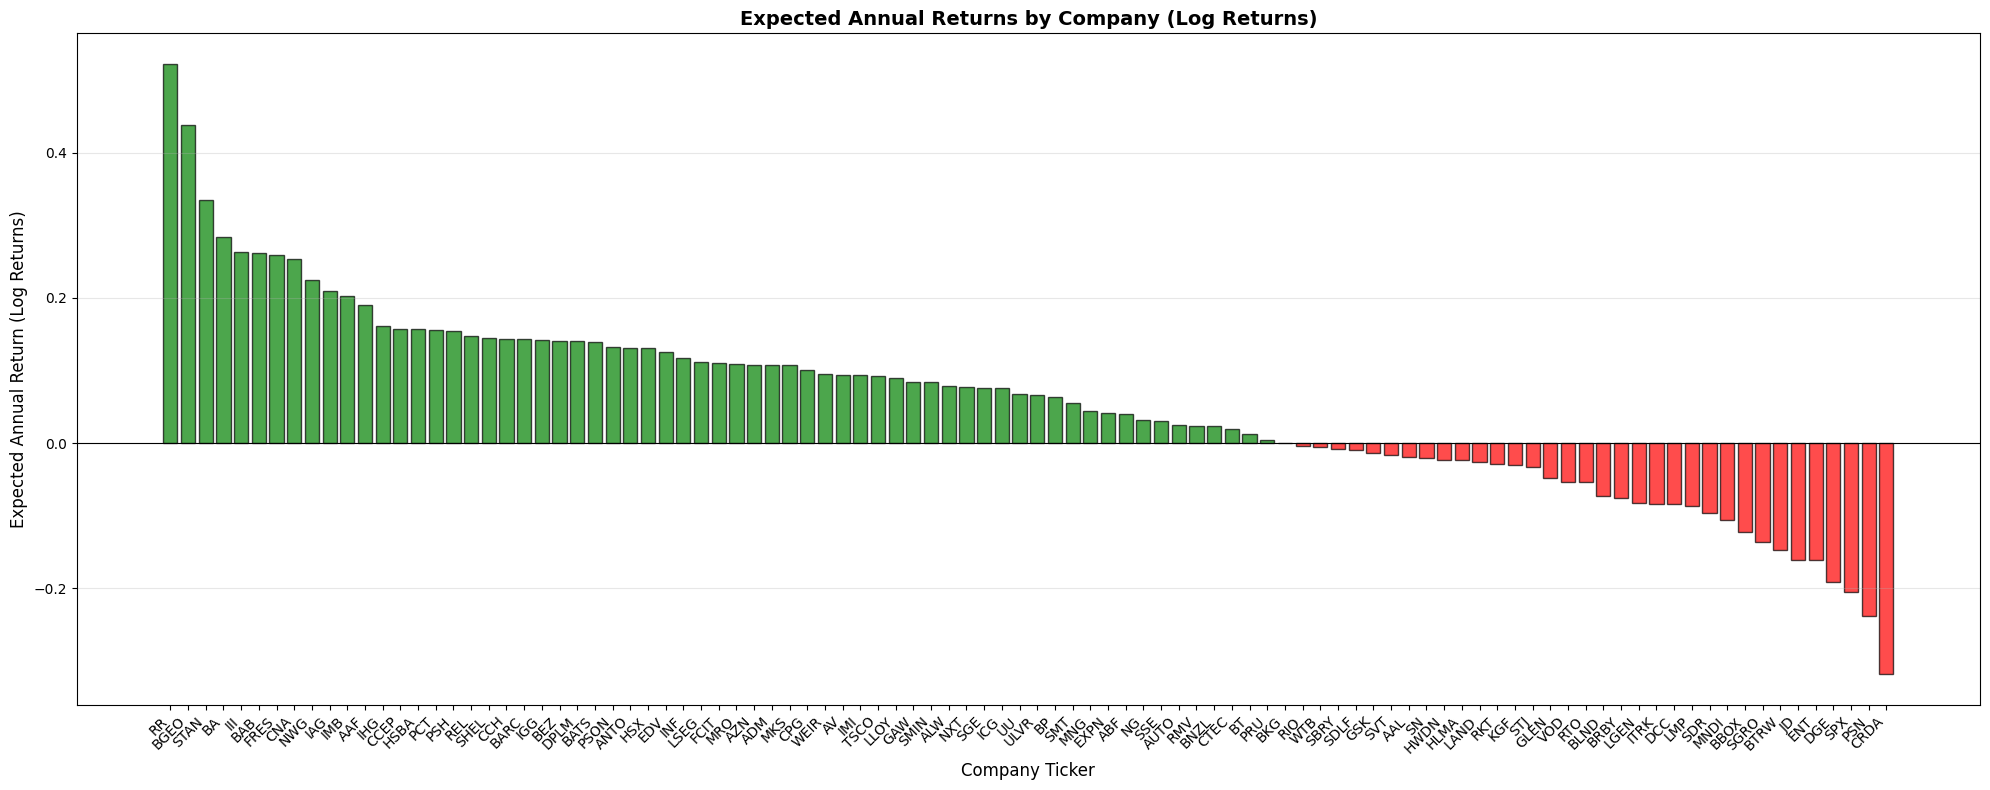


Expected Annual Returns (Log Returns):
RR      0.522262
BGEO    0.438291
STAN    0.334233
BA      0.283845
III     0.262792
          ...   
ENT    -0.161213
DGE    -0.190975
SPX    -0.204439
PSN    -0.238428
CRDA   -0.318355
Length: 98, dtype: float64

Graph saved to: results/expected_returns_by_company.png

Ridge regularization parameter (lambda): 0.0001
Regularized covariance matrix shape: (98, 98)


In [10]:
# ============================================================
# 7) Plot expected annual returns by company
# ============================================================

plt.figure(figsize=(20, 8))
mu_sorted = mu.sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in mu_sorted.values]
plt.bar(range(len(mu_sorted)), mu_sorted.values, color=colors, alpha=0.7, edgecolor='black')
plt.xticks(range(len(mu_sorted)), mu_sorted.index, rotation=45, ha='right', fontsize=10)
plt.ylabel('Expected Annual Return (Log Returns)', fontsize=12)
plt.xlabel('Company Ticker', fontsize=12)
plt.title('Expected Annual Returns by Company (Log Returns)', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/expected_returns_by_company.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nExpected Annual Returns (Log Returns):")
print(mu_sorted)
print(f"\nGraph saved to: results/expected_returns_by_company.png")


# ============================================================
# 8) Ridge regularisation on covariance matrix
# ============================================================

lambda_reg = 1e-4
Sigma_reg = Sigma.values + lambda_reg * np.eye(len(mu))

print(f"\nRidge regularization parameter (lambda): {lambda_reg}")
print(f"Regularized covariance matrix shape: {Sigma_reg.shape}")

In [11]:
# ============================================================
# 9) Load and align ESG scores to expected returns (from summary CSV)
# ============================================================

summary_csv_path = 'results/expected_returns_esg_summary_table.csv'
summary_df = pd.read_csv(summary_csv_path, na_values=['NA']).copy()

if 'Ticker' not in summary_df.columns or 'ESG_Score' not in summary_df.columns:
    raise ValueError(
        "Summary CSV must contain at least 'Ticker' and 'ESG_Score' columns."
    )

summary_df['Ticker'] = summary_df['Ticker'].map(_normalize_asset_name)
summary_df['ESG_Score'] = pd.to_numeric(summary_df['ESG_Score'], errors='coerce')

if 'ESG_Year' in summary_df.columns:
    summary_df['ESG_Year'] = summary_df['ESG_Year'].astype('string')
else:
    summary_df['ESG_Year'] = pd.NA

# Keep one row per ticker if duplicates exist
summary_df = summary_df.drop_duplicates(subset=['Ticker'], keep='first')

# Align ESG fields to current return universe
esg_scores_full = summary_df.set_index('Ticker')['ESG_Score'].reindex(mu.index)
esg_years_full = summary_df.set_index('Ticker')['ESG_Year'].reindex(mu.index)

# Exclude assets without ESG score from optimization universe
dropped_assets = esg_scores_full[esg_scores_full.isna()].index.tolist()
if dropped_assets:
    print(f"Dropping assets with missing ESG score from optimization: {dropped_assets}")

valid_assets = esg_scores_full[esg_scores_full.notna()].index
if len(valid_assets) == 0:
    raise ValueError('No assets with valid ESG scores available for optimization.')

mu = mu.loc[valid_assets]
esg_scores = esg_scores_full.loc[valid_assets]
esg_years = esg_years_full.loc[valid_assets]

# Rebuild regularized covariance for the reduced universe
Sigma_sub = Sigma.loc[valid_assets, valid_assets]
Sigma_reg = Sigma_sub.values + lambda_reg * np.eye(len(valid_assets))

print(f"Loaded summary table from: {summary_csv_path}")
print(f"Optimization universe size after ESG filter: {len(valid_assets)} assets")

esg_aligned_table = pd.DataFrame({
    'Ticker': valid_assets,
    'Expected_Annual_Return': mu.values,
    'ESG_Score': esg_scores.values,
    'ESG_Year': esg_years.values
})

display(esg_aligned_table)

Loaded summary table from: results/expected_returns_esg_summary_table.csv
Optimization universe size after ESG filter: 98 assets


,Ticker,Expected_Annual_Return,ESG_Score,ESG_Year
0,AAF,0.189832,62.0,2024
1,RIO,-0.004228,80.0,2024
2,PSON,0.132428,72.0,2024
3,PSN,-0.238428,69.0,2024
4,PSH,0.155041,36.0,2024
...,...,...,...,...
93,DGE,-0.190975,74.0,2024
94,DCC,-0.083986,36.0,2024
95,CTEC,0.018880,74.0,2024
96,WTB,-0.005650,75.0,2024


In [12]:
# ============================================================
# Summary table: Expected annual returns + ESG score + ESG year
# ============================================================

esg_table = extract_overall_esg_2024_table('ESG').copy()
esg_table['Ticker'] = esg_table['Ticker'].map(_normalize_asset_name)

expected_returns = mu.rename('Expected_Annual_Return').rename_axis('Ticker').reset_index()

summary_table = (
    pd.DataFrame({'Ticker': sorted(set(mu.index).union(set(esg_table['Ticker'])))})
    .merge(expected_returns, on='Ticker', how='left')
    .merge(esg_table[['Ticker', 'ESG_Score', 'Year']], on='Ticker', how='left')
    .rename(columns={'Year': 'ESG_Year'})
)

summary_table = summary_table.sort_values('Ticker').reset_index(drop=True)

# Format for dissertation readability and show NA for missing values
summary_table['Expected_Annual_Return'] = summary_table['Expected_Annual_Return'].map(
    lambda x: f"{x:.4f}" if pd.notna(x) else "NA"
)
summary_table['ESG_Score'] = summary_table['ESG_Score'].map(
    lambda x: f"{x:.2f}" if pd.notna(x) else "NA"
)
summary_table['ESG_Year'] = summary_table['ESG_Year'].map(
    lambda x: str(int(x)) if pd.notna(x) and str(x).strip().isdigit() else (str(x) if pd.notna(x) else "NA")
)

display(summary_table)

# Optional: export for dissertation appendix/tables
summary_table.to_csv('results/expected_returns_esg_summary_table.csv', index=False)
print("Saved: results/expected_returns_esg_summary_table.csv")

,Ticker,Expected_Annual_Return,ESG_Score,ESG_Year
0,AAF,0.1898,62.00,2024
1,AAL,-0.0188,74.00,2024
2,ABF,0.0399,63.00,2024
3,ADM,0.1074,53.00,2024
4,ALW,0.0780,56.00,2024
...,...,...,...,...
94,ULVR,0.0667,83.00,2024
95,UU,0.0679,76.00,2024
96,VOD,-0.0537,83.00,2024
97,WEIR,0.0948,70.00,2024


Saved: results/expected_returns_esg_summary_table.csv


In [ ]:
# ============================================================
# Dissertation-ready table using Great Tables
# ============================================================

import pandas as pd
import webbrowser
from pathlib import Path
from great_tables import GT, md

# Load the summary table you already generated
tbl_df = pd.read_csv('results/expected_returns_esg_summary_table.csv', na_values=['NA'])


tbl_df = tbl_df[['Ticker', 'Expected_Annual_Return', 'ESG_Score', 'ESG_Year']].copy()


tbl_df['ESG_Year'] = tbl_df['ESG_Year'].apply(
    lambda x: str(int(float(x))) if pd.notna(x) else pd.NA
)

gt_table = (
    GT(tbl_df)
    .tab_header(
        title=md('**Expected Annual Returns and ESG Scores by Stock**'),
        subtitle='Values used in portfolio optimisation analysis'
    )
    .cols_label(
        Ticker='Ticker',
        Expected_Annual_Return='Expected Annual Return',
        ESG_Score='ESG Score',
        ESG_Year='ESG Year'
    )
    .fmt_number(columns=['Expected_Annual_Return'], decimals=4)
    .fmt_number(columns=['ESG_Score'], decimals=2)
    .sub_missing(columns=['Expected_Annual_Return', 'ESG_Score', 'ESG_Year'], missing_text='NA')
    .tab_source_note('Source: Historical returns and extracted Refinitiv ESG files')
)

# Show the styled table in the notebook
gt_table


output_path = Path('results/expected_returns_esg_summary_table_gt.html')
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(gt_table.as_raw_html())

print(f'Saved: {output_path}')


try:
    webbrowser.open(output_path.resolve().as_uri())
    print('Opened table in your default browser.')
except Exception as err:
    print(f'Could not auto-open browser: {err}')

Saved: results/expected_returns_esg_summary_table_gt.html
Opened table in your default browser.


In [14]:
# ============================================================
# 10) Set up optimization parameters
# ============================================================

n = len(mu)  # number of assets
w0 = np.ones(n) / n  # initial guess (equal weights)
bounds = [(0, 1)] * n  # long-only constraints: each weight between 0 and 1
rf = 0.02  # risk-free rate (annual)

print(f"Number of assets: {n}")
print(f"Initial weights (equal): {w0}")
print(f"Risk-free rate: {rf * 100}%")

Number of assets: 98
Initial weights (equal): [0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408 0.01020408
 0.01020408 0.01

In [15]:
# ============================================================
# 11) Portfolio variance helper
# ============================================================

def portfolio_variance(w, Sigma_reg):
    """Calculate portfolio variance given weights and covariance matrix."""
    return w.T @ Sigma_reg @ w

# Portfolio variance shows the overall risk of the portfolio
# based on the weights and the covariance matrix.

In [16]:
# ============================================================
# 12) Negative Sharpe ratio helper
# ============================================================

def neg_sharpe(w, mu, Sigma_reg, rf):
    """Calculate negative Sharpe ratio (for minimization)."""
    ret = w @ mu.values
    vol = np.sqrt(w.T @ Sigma_reg @ w) + 1e-12
    return -(ret - rf) / vol

# Negative Sharpe ratio is used as objective function for optimization,
# maximizing Sharpe (minimizing negative Sharpe).
# Sharpe = excess return / volatility (standard deviation of portfolio returns).

In [17]:
# ============================================================
# 13) ESG constraint helper
# ============================================================

def esg_constraint(w, esg_scores, esg_min):
    """ESG constraint: weighted average ESG score >= esg_min."""
    return (w @ esg_scores.values) - esg_min  # must be >= 0

# The ESG constraint ensures that the weighted average ESG score
# of the portfolio meets or exceeds a specified minimum threshold (esg_min).

In [18]:
# ============================================================
# 14) Portfolio statistics helper
# ============================================================

def portfolio_stats(w, mu, Sigma_reg, rf, esg_scores):
    """Calculate portfolio return, volatility, Sharpe ratio, and ESG score."""
    ret = float(w @ mu.values)
    vol = float(np.sqrt(w.T @ Sigma_reg @ w) + 1e-12)
    sharpe = float((ret - rf) / vol)
    esg = float(w @ esg_scores.values)
    return ret, vol, sharpe, esg

# Returns a tuple of:
#   - ret: portfolio annual return
#   - vol: portfolio annual volatility (standard deviation)
#   - sharpe: Sharpe ratio (excess return per unit of risk)
#   - esg: weighted average ESG score

In [19]:
# ============================================================
# 15) Concentration metrics helper
# ============================================================

def concentration_metrics(w):
    """Calculate portfolio concentration metrics: HHI, effective holdings, max weight."""
    hhi = float(np.sum(w**2))
    # Herfindahl-Hirschman Index shows concentration (higher = more concentrated)

    eff_n = float(1.0 / hhi) if hhi > 0 else np.inf
    # Effective number of holdings: inverse of HHI
    # Estimates how many equally-weighted assets would match current concentration
    # Higher value = more diversified portfolio

    max_w = float(np.max(w))
    # Maximum weight: largest single position in portfolio
    # Indicates if heavily concentrated in single asset

    return hhi, eff_n, max_w

In [20]:
# ============================================================
# 16) Compute efficient frontier
# ============================================================

def compute_efficient_frontier(mu, Sigma_reg, bounds, esg_scores=None, esg_min=None, num_points=40):
    """
    Compute efficient frontier for long-only Markowitz with optional ESG min constraint.
    Returns (vol_list, ret_list, weights_list).
    """
    target_returns = np.linspace(mu.min(), mu.max(), num_points)
    # Target returns span from minimum to maximum expected asset returns
    # allowing efficient frontier to be computed across full return range

    vols, rets, wts = [], [], []
    w_prev = np.ones(len(mu)) / len(mu)  # warm start: equal-weighted portfolio

    for r_target in target_returns:
        constraints = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1},  # weights sum to 1
            {"type": "eq", "fun": lambda w, r=r_target: w @ mu.values - r},  # target return
        ]

        if esg_scores is not None and esg_min is not None:
            constraints.append(
                {"type": "ineq", "fun": lambda w, m=esg_min: esg_constraint(w, esg_scores, m)}
            )  # ESG minimum threshold constraint

        res = minimize(
            fun=lambda w: portfolio_variance(w, Sigma_reg),
            x0=w_prev,
            method="SLSQP",
            bounds=bounds,
            constraints=tuple(constraints),
            options={"maxiter": 3000}
        )

        if res.success:
            vols.append(float(np.sqrt(res.fun)))
            rets.append(float(r_target))
            wts.append(res.x)
            w_prev = res.x  # warm start for next iteration

    return vols, rets, wts

In [21]:
# ============================================================
# 17) Plot all efficient frontiers
# ============================================================

def plot_all_frontiers(output_dir, baseline_vols, baseline_rets):
    """Plot all efficient frontiers across different ESG constraints."""
    import colorsys
    frontier_csvs = sorted(glob.glob(os.path.join(output_dir, "esg_constraint_*_frontier_weights.csv")))

    plt.figure(figsize=(10, 7))

    if len(baseline_vols) > 1:
        plt.plot(baseline_vols, baseline_rets, color="black", linewidth=2.4, label="No ESG constraint")

    plotted_any = False
    # Create dark, high-contrast colors (no light pastel tones).
    n_curves = max(len(frontier_csvs), 1)
    curve_colors = []
    for i in range(n_curves):
        hue = i / n_curves
        # HLS: keep lightness low for darker tones and high saturation for contrast
        rgb = colorsys.hls_to_rgb(hue, 0.34, 0.9)
        curve_colors.append(rgb)

    for idx, csv_path in enumerate(frontier_csvs):
        try:
            df = pd.read_csv(csv_path)
        except Exception:
            continue

        if "Volatility" not in df.columns or "Return" not in df.columns:
            continue

        df = df.sort_values("Return")
        if len(df) < 2:
            continue

        esg_tag = os.path.basename(csv_path).split("_")[-3]  # extract ESG value from filename
        plt.plot(
            df["Volatility"],
            df["Return"],
            marker="o",
            markersize=3,
            linewidth=1.4,
            color=curve_colors[idx],
            label=f"ESG >= {esg_tag}"
        )
        plotted_any = True

    if plotted_any:
        plt.xlabel("Volatility")
        plt.ylabel("Expected Return")
        plt.title("Efficient Frontiers Across ESG Constraints")
        plt.grid(True, alpha=0.3)
        plt.legend(ncol=2, fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "all_esg_frontiers.png"), dpi=300)
        plt.close()

In [22]:
# ============================================================
# 18) Plot max Sharpe points by ESG constraint
# ============================================================

def plot_sharpe_points(esg_vals, ret_vals, vol_vals, output_dir):
    """Plot max Sharpe return and volatility across ESG constraints."""
    if len(esg_vals) < 1:
        return

    plot_df = pd.DataFrame({
        "ESG": esg_vals,
        "Return": ret_vals,
        "Volatility": vol_vals,
    }).sort_values("ESG")

    fig, ax_ret = plt.subplots(figsize=(10, 6))

    ax_ret.plot(
        plot_df["ESG"],
        plot_df["Return"],
        marker="o",
        linewidth=1.5,
        color="tab:blue",
        label="Max Sharpe return",
    )
    ax_ret.set_xlabel("ESG Constraint (Minimum)")
    ax_ret.set_ylabel("Expected Return", color="tab:blue")
    ax_ret.tick_params(axis="y", labelcolor="tab:blue")
    ax_ret.grid(True, alpha=0.3)

    ax_vol = ax_ret.twinx()
    ax_vol.plot(
        plot_df["ESG"],
        plot_df["Volatility"],
        marker="s",
        linewidth=1.5,
        color="tab:orange",
        label="Max Sharpe volatility",
    )
    ax_vol.set_ylabel("Volatility", color="tab:orange")
    ax_vol.tick_params(axis="y", labelcolor="tab:orange")

    plt.title("Max Sharpe Points by ESG Constraint")
    fig.tight_layout()
    plt.savefig(os.path.join(output_dir, "max_sharpe_points_by_esg.png"), dpi=300)
    plt.close()

In [23]:
# ============================================================
# 19) Run portfolio optimisation and save all efficient frontiers
# ============================================================

output_dir = 'results_frontiers'
os.makedirs(output_dir, exist_ok=True)

# Ensure optimization dimensions match the filtered ESG universe
n = len(mu)
w0 = np.ones(n) / n
bounds = [(0, 1)] * n

print('Running portfolio optimisation...')
print(f'Assets in optimisation universe: {n}')
print(f'Output directory: {output_dir}')

# Remove old ESG frontier files so plots only reflect this run
for old_csv in glob.glob(os.path.join(output_dir, 'esg_constraint_*_frontier_weights.csv')):
    try:
        os.remove(old_csv)
    except OSError:
        pass

# 1) Baseline frontier (no ESG constraint)
baseline_vols, baseline_rets, baseline_wts = compute_efficient_frontier(
    mu=mu,
    Sigma_reg=Sigma_reg,
    bounds=bounds,
    esg_scores=None,
    esg_min=None,
    num_points=60,
 )

baseline_df = pd.DataFrame({
    'Volatility': baseline_vols,
    'Return': baseline_rets,
})
baseline_df.to_csv(os.path.join(output_dir, 'baseline_frontier.csv'), index=False)
print(f'Baseline frontier points: {len(baseline_df)}')

# 2) ESG-constrained frontiers with 30 equally spaced constraints
esg_min_value = float(esg_scores.min())
esg_max_value = float(esg_scores.max())
esg_step = (esg_max_value - esg_min_value) / 30.0
esg_thresholds = [esg_min_value + i * esg_step for i in range(30)]

print(
    f'ESG range: [{esg_min_value:.4f}, {esg_max_value:.4f}] | '
    f'Step: {esg_step:.4f} | Threshold count: {len(esg_thresholds)}'
 )

esg_summary_rows = []

for esg_min in esg_thresholds:
    vols, rets, wts = compute_efficient_frontier(
        mu=mu,
        Sigma_reg=Sigma_reg,
        bounds=bounds,
        esg_scores=esg_scores,
        esg_min=esg_min,
        num_points=60,
    )

    if len(vols) == 0:
        print(f'ESG >= {esg_min:.4f}: no feasible frontier points')
        continue

    frontier_data = {
        'Volatility': vols,
        'Return': rets,
    }
    for i, ticker in enumerate(mu.index):
        frontier_data[ticker] = [w[i] for w in wts]

    frontier_df = pd.DataFrame(frontier_data).sort_values('Return').reset_index(drop=True)
    esg_tag = f"{esg_min:.4f}".rstrip('0').rstrip('.')
    frontier_path = os.path.join(output_dir, f'esg_constraint_{esg_tag}_frontier_weights.csv')
    frontier_df.to_csv(frontier_path, index=False)

    sharpe_ratios = [(r - rf) / v if v > 0 else np.nan for r, v in zip(rets, vols)]
    max_idx = int(np.nanargmax(sharpe_ratios))

    ret, vol, sharpe, esg_val = portfolio_stats(wts[max_idx], mu, Sigma_reg, rf, esg_scores)
    hhi, eff_n, max_w = concentration_metrics(wts[max_idx])

    esg_summary_rows.append({
        'esg_min': esg_min,
        'ret': ret,
        'vol': vol,
        'sharpe': sharpe,
        'esg_achieved': esg_val,
        'conc_hhi': hhi,
        'eff_n': eff_n,
        'max_w': max_w,
        'frontier_points': len(frontier_df),
    })

    print(f'ESG >= {esg_min:.4f}: {len(frontier_df)} points saved')

results_df = pd.DataFrame(esg_summary_rows).sort_values('esg_min').reset_index(drop=True)
results_path = os.path.join(output_dir, 'optimization_results.csv')
results_df.to_csv(results_path, index=False)

print('\nDone.')
print(f'Saved: {os.path.join(output_dir, "baseline_frontier.csv")}')
print(f'Saved: {results_path}')
display(results_df)

Running portfolio optimisation...
Assets in optimisation universe: 98
Output directory: results_frontiers
Baseline frontier points: 60
ESG range: [15.0000, 93.0000] | Step: 2.6000 | Threshold count: 30
ESG >= 15.0000: 60 points saved
ESG >= 17.6000: 60 points saved
ESG >= 20.2000: 60 points saved
ESG >= 22.8000: 60 points saved
ESG >= 25.4000: 60 points saved
ESG >= 28.0000: 60 points saved
ESG >= 30.6000: 60 points saved
ESG >= 33.2000: 60 points saved
ESG >= 35.8000: 60 points saved
ESG >= 38.4000: 60 points saved
ESG >= 41.0000: 60 points saved
ESG >= 43.6000: 60 points saved
ESG >= 46.2000: 60 points saved
ESG >= 48.8000: 60 points saved
ESG >= 51.4000: 60 points saved
ESG >= 54.0000: 60 points saved
ESG >= 56.6000: 60 points saved
ESG >= 59.2000: 60 points saved
ESG >= 61.8000: 60 points saved
ESG >= 64.4000: 60 points saved
ESG >= 67.0000: 60 points saved
ESG >= 69.6000: 60 points saved
ESG >= 72.2000: 60 points saved
ESG >= 74.8000: 60 points saved
ESG >= 77.4000: 57 points save

KeyboardInterrupt: 

In [ ]:
# Generate one combined chart: baseline + all ESG-constrained frontiers
plot_all_frontiers(output_dir, baseline_vols, baseline_rets)
print('Saved: results_frontiers/all_esg_frontiers.png')

Saved: results_frontiers/all_esg_frontiers.png


In [ ]:
# ============================================================
# 20) Portfolio weight composition vs ESG at fixed expected returns
# ============================================================

target_returns = [-0.18, -0.08, 0.0, 0.08, 0.18, 0.28]
frontier_csvs = sorted(glob.glob(os.path.join(output_dir, 'esg_constraint_*_frontier_weights.csv')))

if len(frontier_csvs) == 0:
    raise ValueError('No ESG frontier CSV files found. Run the optimisation cell first.')

for target_ret in target_returns:
    esg_vals = []
    weights_rows = []

    for csv_path in frontier_csvs:
        try:
            df = pd.read_csv(csv_path)
        except Exception:
            continue

        if 'Return' not in df.columns or 'Volatility' not in df.columns:
            continue

        # Extract ESG threshold from filename: esg_constraint_{value}_frontier_weights.csv
        try:
            esg_val = float(os.path.basename(csv_path).split('_')[-3])
        except ValueError:
            continue

        df = df.sort_values('Return').reset_index(drop=True)
        if len(df) < 2:
            continue

        ret_min = df['Return'].min()
        ret_max = df['Return'].max()
        if not (ret_min <= target_ret <= ret_max):
            continue

        asset_cols = [c for c in df.columns if c not in ['Volatility', 'Return']]
        interpolated_weights = {
            col: float(np.interp(target_ret, df['Return'].values, df[col].values))
            for col in asset_cols
        }

        esg_vals.append(esg_val)
        weights_rows.append(interpolated_weights)

    if len(esg_vals) == 0:
        print(f'No feasible ESG frontiers cover target return {target_ret:.1f}.')
        continue

    comp_df = pd.DataFrame(weights_rows, index=esg_vals).sort_index()
    comp_df = comp_df.clip(lower=0.0)
    comp_df = comp_df.div(comp_df.sum(axis=1), axis=0).fillna(0.0)

    # Keep assets with meaningful allocation to improve readability
    comp_df = comp_df.loc[:, comp_df.max(axis=0) >= 0.01]

    plt.figure(figsize=(11, 6))

    # Create a distinct colour spectrum for the stocks in this composition plot
    n_assets = len(comp_df.columns)
    asset_colors = []

    for i in range(n_assets):
        hue = i / (n_assets + 1)
        rgb = colorsys.hls_to_rgb(hue, 0.45, 0.85)
        asset_colors.append(rgb)

    plt.stackplot(
        comp_df.index,
        (comp_df * 100.0).T.values,
        labels=comp_df.columns,
        colors=asset_colors,
        alpha=0.9
    )



    plt.xlabel('ESG Constraint (Minimum)')
    plt.ylabel('Portfolio Weight (%)')
    plt.title(f'Portfolio Composition vs ESG Constraint at Expected Return {target_ret:.0%}')
    plt.grid(True, alpha=0.3, axis='y')
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    plt.tight_layout()

    ret_tag = str(target_ret).replace('-', 'neg_').replace('.', '_')
    out_path = os.path.join(output_dir, f'composition_at_return_{ret_tag}.png')
    plt.savefig(out_path, dpi=300)
    plt.close()
    print(f'Saved: {out_path}')

Saved: results_frontiers/composition_at_return_neg_0_18.png
Saved: results_frontiers/composition_at_return_neg_0_08.png
Saved: results_frontiers/composition_at_return_0_0.png
Saved: results_frontiers/composition_at_return_0_08.png
Saved: results_frontiers/composition_at_return_0_18.png
Saved: results_frontiers/composition_at_return_0_28.png


In [ ]:
# ============================================================
# 21) Graph of max Sharpe expected return and volatility vs ESG
# ============================================================

if 'results_df' not in globals() or results_df.empty:
    raise ValueError('results_df is empty. Run the optimisation cell first.')

plot_sharpe_points(
    esg_vals=results_df['esg_min'].tolist(),
    ret_vals=results_df['ret'].tolist(),
    vol_vals=results_df['vol'].tolist(),
    output_dir=output_dir,
 )

print('Saved: results_frontiers/max_sharpe_points_by_esg.png')

Saved: results_frontiers/max_sharpe_points_by_esg.png


Saved HHI results to: results_frontiers/frontier_hhi_results.csv


,ESG_Min,Return,Volatility,HHI,Effective_Holdings
0,15.0,-0.318355,0.282449,1.000000,1.000000
1,15.0,-0.304108,0.258444,0.730917,1.368145
2,15.0,-0.289860,0.238352,0.571512,1.749743
3,15.0,-0.275612,0.220779,0.461388,2.167371
4,15.0,-0.261364,0.206371,0.400545,2.496600


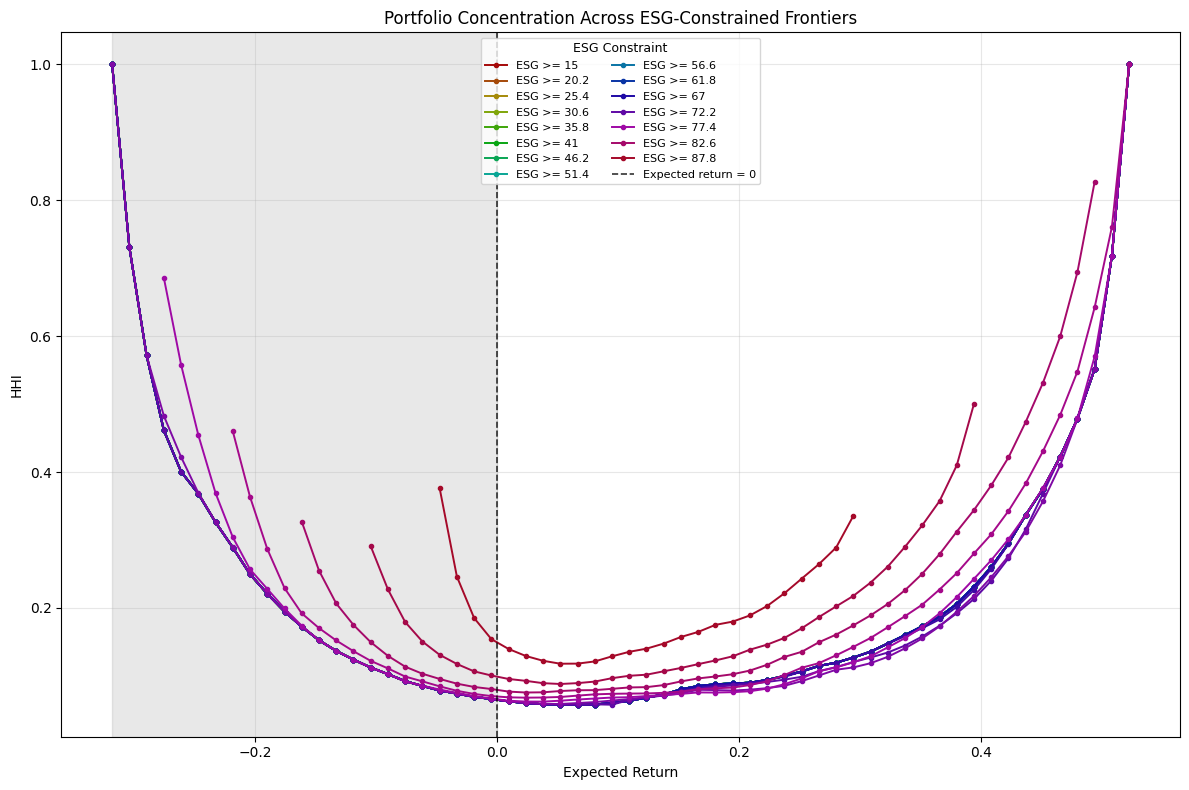

Saved: results_frontiers/hhi_across_esg_frontiers_clean.png


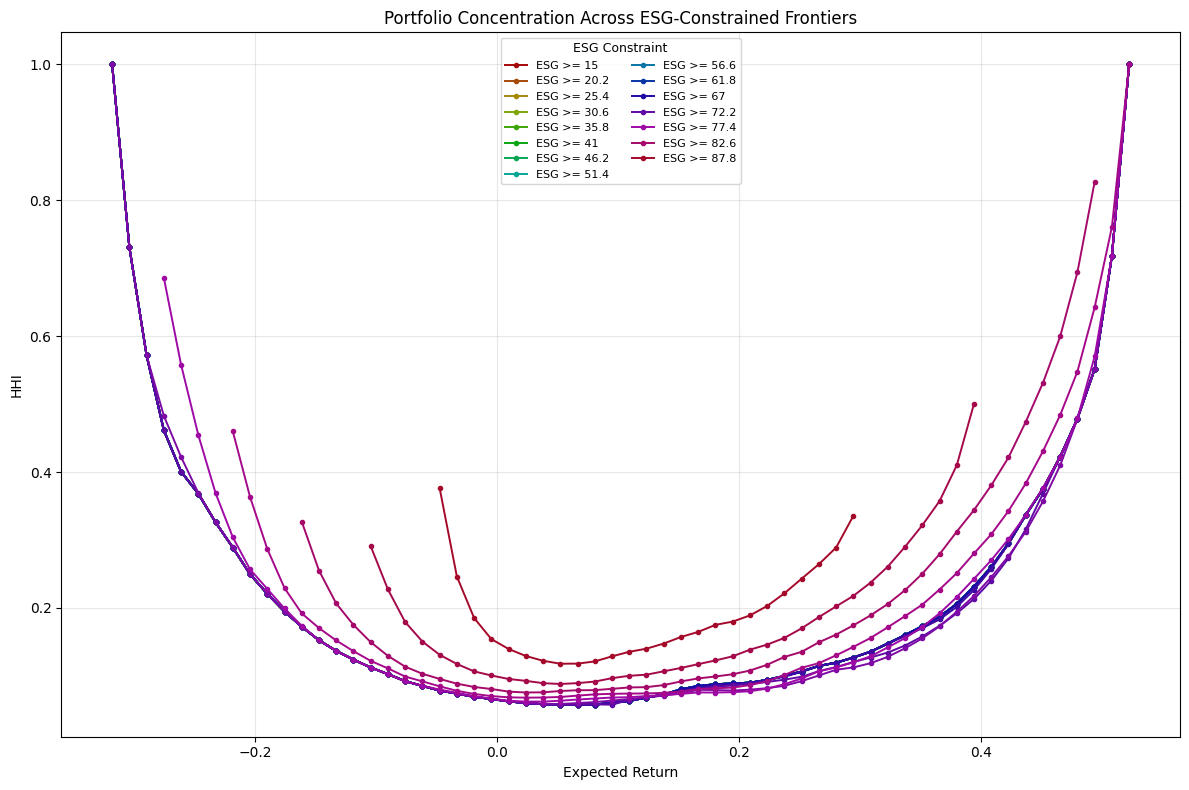

Saved: results_frontiers/hhi_across_esg_frontiers_clean.png


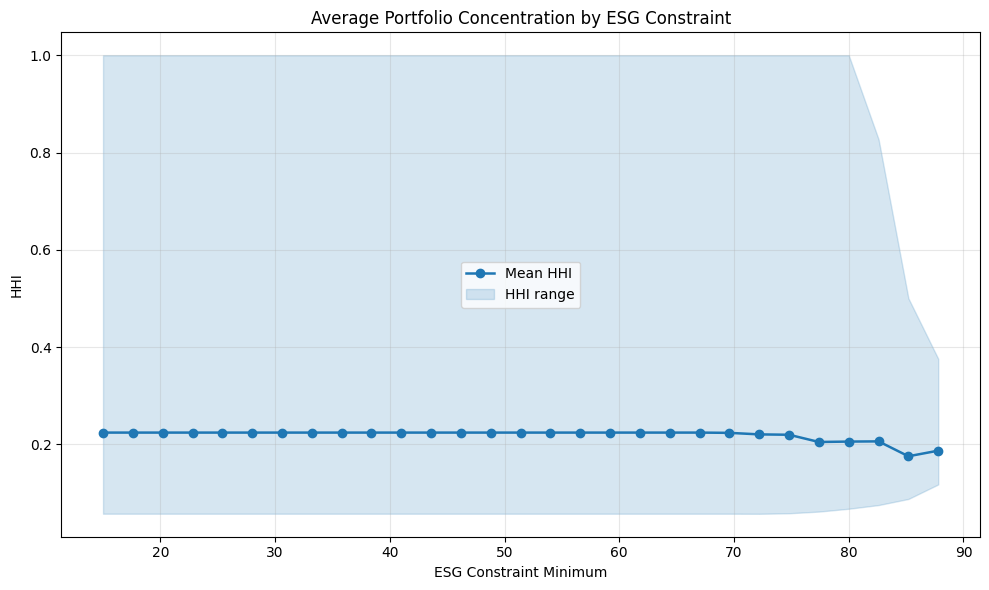

Saved: results_frontiers/average_hhi_by_esg_constraint.png


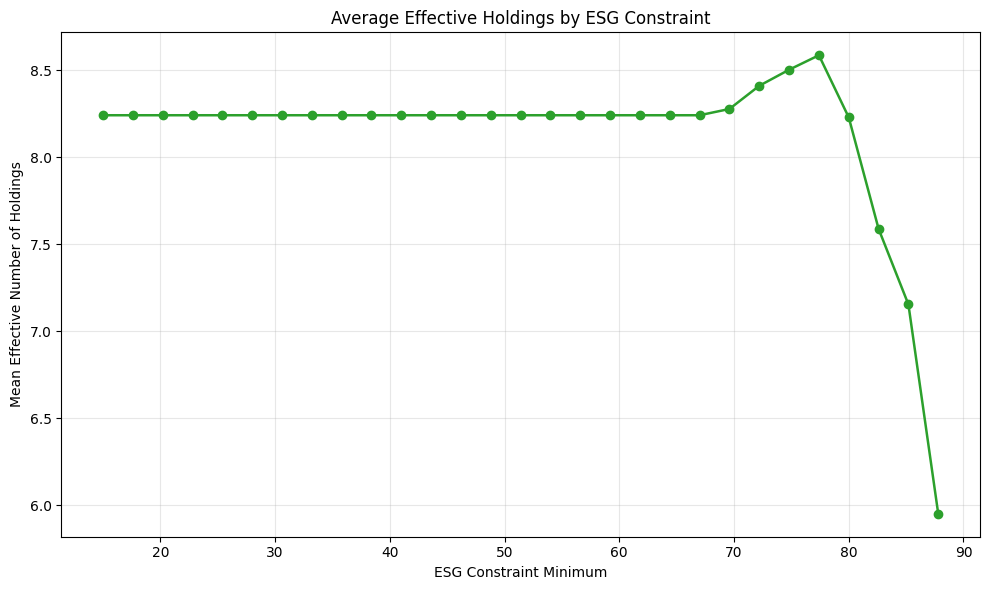

Saved: results_frontiers/average_effective_holdings_by_esg_constraint.png


In [ ]:
# ============================================================
# Visualise HHI across all ESG-constrained efficient frontiers
# Same colour style as all efficient frontier graph
# ============================================================

import os
import glob
import colorsys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

output_dir = "results_frontiers"

frontier_csvs = sorted(
    glob.glob(os.path.join(output_dir, "esg_constraint_*_frontier_weights.csv"))
)

if len(frontier_csvs) == 0:
    raise ValueError("No ESG frontier CSV files found. Run the optimisation cell first.")

hhi_rows = []

for csv_path in frontier_csvs:
    df = pd.read_csv(csv_path)

    if "Volatility" not in df.columns or "Return" not in df.columns:
        continue


    esg_min = float(os.path.basename(csv_path).split("_")[-3])

    asset_cols = [c for c in df.columns if c not in ["Volatility", "Return"]]
    weights = df[asset_cols].values

    # HHI = sum of squared portfolio weights
    hhi = np.sum(weights ** 2, axis=1)

    temp = pd.DataFrame({
        "ESG_Min": esg_min,
        "Return": df["Return"],
        "Volatility": df["Volatility"],
        "HHI": hhi,
        "Effective_Holdings": 1 / hhi
    })

    hhi_rows.append(temp)

hhi_df = pd.concat(hhi_rows, ignore_index=True)

# Save HHI data
hhi_path = os.path.join(output_dir, "frontier_hhi_results.csv")
hhi_df.to_csv(hhi_path, index=False)

print(f"Saved HHI results to: {hhi_path}")
display(hhi_df.head())

# ============================================================
# Plot HHI vs Expected Return for all ESG frontiers
# ============================================================

plt.figure(figsize=(12, 8))

esg_levels = sorted(hhi_df["ESG_Min"].unique())


n_curves = max(len(esg_levels), 1)
curve_colors = []

for i in range(n_curves):
    hue = i / n_curves
    rgb = colorsys.hls_to_rgb(hue, 0.34, 0.9)
    curve_colors.append(rgb)

for idx, esg_min in enumerate(esg_levels):
    group = (
        hhi_df[hhi_df["ESG_Min"] == esg_min]
        .sort_values("Return")
    )

    
    show_label = (idx % 2 == 0) or (idx == len(esg_levels) - 1)

    plt.plot(
        group["Return"],
        group["HHI"],
        marker="o",
        markersize=3,
        linewidth=1.4,
        color=curve_colors[idx],
        label=f"ESG >= {esg_min:g}" if show_label else None
    )


x_min = hhi_df["Return"].min()

plt.axvspan(
    x_min,
    0.0,
    color="grey",
    alpha=0.18
)

# Add a clear zero-return reference line
plt.axvline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="Expected return = 0"
)

plt.xlabel("Expected Return")
plt.ylabel("HHI")
plt.title("Portfolio Concentration Across ESG-Constrained Frontiers")
plt.grid(True, alpha=0.3)

plt.legend(
    ncol=2,
    fontsize=8,
    title="ESG Constraint",
    title_fontsize=9
)

plt.tight_layout()

out_path = os.path.join(output_dir, "hhi_across_esg_frontiers_clean.png")
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")

# ============================================================
# Plot HHI vs Expected Return for all ESG frontiers
# ============================================================

plt.figure(figsize=(12, 8))

esg_levels = sorted(hhi_df["ESG_Min"].unique())

# Create dark, high-contrast colours, matching the efficient frontier graph style
n_curves = max(len(esg_levels), 1)
curve_colors = []

for i in range(n_curves):
    hue = i / n_curves
    rgb = colorsys.hls_to_rgb(hue, 0.34, 0.9)
    curve_colors.append(rgb)

for idx, esg_min in enumerate(esg_levels):
    group = (
        hhi_df[hhi_df["ESG_Min"] == esg_min]
        .sort_values("Return")
    )

    # Label every second frontier, plus the final one, to keep legend readable
    show_label = (idx % 2 == 0) or (idx == len(esg_levels) - 1)

    plt.plot(
        group["Return"],
        group["HHI"],
        marker="o",
        markersize=3,
        linewidth=1.4,
        color=curve_colors[idx],
        label=f"ESG >= {esg_min:g}" if show_label else None
    )

plt.xlabel("Expected Return")
plt.ylabel("HHI")
plt.title("Portfolio Concentration Across ESG-Constrained Frontiers")
plt.grid(True, alpha=0.3)

plt.legend(
    ncol=2,
    fontsize=8,
    title="ESG Constraint",
    title_fontsize=9
)

plt.tight_layout()

out_path = os.path.join(output_dir, "hhi_across_esg_frontiers_clean.png")
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


#


# ============================================================
# Plot average HHI by ESG constraint
# ============================================================

avg_hhi = (
    hhi_df
    .groupby("ESG_Min", as_index=False)
    .agg(
        Mean_HHI=("HHI", "mean"),
        Min_HHI=("HHI", "min"),
        Max_HHI=("HHI", "max"),
        Mean_Effective_Holdings=("Effective_Holdings", "mean")
    )
)

plt.figure(figsize=(10, 6))

plt.plot(
    avg_hhi["ESG_Min"],
    avg_hhi["Mean_HHI"],
    marker="o",
    linewidth=1.8,
    color="tab:blue",
    label="Mean HHI"
)

plt.fill_between(
    avg_hhi["ESG_Min"],
    avg_hhi["Min_HHI"],
    avg_hhi["Max_HHI"],
    color="tab:blue",
    alpha=0.18,
    label="HHI range"
)

plt.xlabel("ESG Constraint Minimum")
plt.ylabel("HHI")
plt.title("Average Portfolio Concentration by ESG Constraint")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = os.path.join(output_dir, "average_hhi_by_esg_constraint.png")
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


# ============================================================
# Plot average effective holdings by ESG constraint
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    avg_hhi["ESG_Min"],
    avg_hhi["Mean_Effective_Holdings"],
    marker="o",
    linewidth=1.8,
    color="tab:green"
)

plt.xlabel("ESG Constraint Minimum")
plt.ylabel("Mean Effective Number of Holdings")
plt.title("Average Effective Holdings by ESG Constraint")
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = os.path.join(output_dir, "average_effective_holdings_by_esg_constraint.png")
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


In [ ]:
# ============================================================
# Forward testing: load and clean future price data
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

forward_folder = "Forward testing"
frontier_dir = "results_frontiers"
forward_output_dir = "forward_testing_results"

os.makedirs(forward_output_dir, exist_ok=True)


def _normalize_forward_asset_name(name):
    """
    Normalise ticker names across Historical, ESG, and Forward testing files.
    Handles suffixes such as _H, _E, and _N.
    Also handles names like NG._N -> NG.
    """
    name = str(name).strip().upper()

    for suffix in ["_H", "_E", "_N"]:
        if name.endswith(suffix):
            name = name[:-2]

    name = name.rstrip(".")
    return name


def clean_forward_refinitiv_file(path, asset_name):
    raw = pd.read_excel(path)

    header_idx = raw.index[
        raw.apply(
            lambda r: r.astype(str).str.contains("Exchange Date", case=False, na=False)
        ).any(axis=1)
    ][0]

    cols = raw.loc[header_idx].tolist()
    df = raw.loc[header_idx + 1:].copy()
    df.columns = cols

    df = df[["Exchange Date", "Close"]].dropna()
    df["Exchange Date"] = pd.to_datetime(df["Exchange Date"])
    df = df.sort_values("Exchange Date")

    prices = df.set_index("Exchange Date")["Close"].astype(float)
    prices.name = asset_name

    return prices


forward_price_series = []
forward_load_report = []

for file_path in sorted(Path(forward_folder).glob("*.ods")):
    if file_path.name.startswith(".~lock."):
        continue

    ticker = _normalize_forward_asset_name(file_path.stem)

    try:
        s = clean_forward_refinitiv_file(str(file_path), ticker)
        forward_price_series.append(s)

        forward_load_report.append({
            "Ticker": ticker,
            "Rows": len(s),
            "Start_Date": s.index.min(),
            "End_Date": s.index.max(),
            "Status": "ok",
            "Issue": "none"
        })

    except Exception as err:
        forward_load_report.append({
            "Ticker": ticker,
            "Rows": 0,
            "Start_Date": pd.NaT,
            "End_Date": pd.NaT,
            "Status": "failed",
            "Issue": str(err)
        })

if len(forward_price_series) == 0:
    raise ValueError("No valid forward testing files were loaded.")

forward_prices = pd.concat(forward_price_series, axis=1).sort_index()
forward_load_report_df = pd.DataFrame(forward_load_report).sort_values("Ticker")

forward_load_report_path = os.path.join(
    forward_output_dir,
    "forward_data_load_report.csv"
)
forward_load_report_df.to_csv(forward_load_report_path, index=False)

print(f"Forward prices shape: {forward_prices.shape}")
print(f"Forward period: {forward_prices.index.min().date()} to {forward_prices.index.max().date()}")
print(f"Saved load report to: {forward_load_report_path}")

display(forward_load_report_df)
display(forward_prices.head())


Forward prices shape: (150, 99)
Forward period: 2025-09-01 to 2026-03-31
Saved load report to: forward_testing_results/forward_data_load_report.csv


,Ticker,Rows,Start_Date,End_Date,Status,Issue
0,AAF,149,2025-09-01,2026-03-31,ok,none
1,AAL,149,2025-09-01,2026-03-31,ok,none
2,ABF,149,2025-09-01,2026-03-31,ok,none
3,ADM,149,2025-09-01,2026-03-31,ok,none
4,ALW,149,2025-09-01,2026-03-31,ok,none
...,...,...,...,...,...,...
94,ULVR,149,2025-09-01,2026-03-31,ok,none
95,UU,149,2025-09-01,2026-03-31,ok,none
96,VOD,149,2025-09-01,2026-03-31,ok,none
97,WEIR,149,2025-09-01,2026-03-31,ok,none


,AAF,AAL,ABF,ADM,ALW,ANTO,AUTO,AV,AZN,BA,...,SSE,STAN,STJ,SVT,TSCO,ULVR,UU,VOD,WEIR,WTB
Exchange Date,,,,,,,,,,,,,,,,,,,,,
2025-09-01,223.0,2264.0,2190.0,3574.238168,1252.0,2146.0,800.0,647.2,11850.0,1791.0,...,1676.5,1377.0,1266.0,2538.0,431.0,4996.119942,1121.5,87.88,2466.0,3125.0
2025-09-02,218.6,2236.0,2185.0,3536.551972,1252.0,2131.0,770.8,630.2,11904.0,1767.5,...,1614.5,1369.5,1220.5,2486.0,424.9,5064.677334,1091.5,87.48,2464.0,2983.0
2025-09-03,215.2,2288.0,2205.0,3494.898808,1250.0,2197.0,776.0,630.0,12210.0,1777.5,...,1612.0,1360.0,1230.5,2500.0,431.1,5101.098449,1100.0,87.08,2460.0,3026.0
2025-09-04,220.6,2260.0,2228.0,3444.000000,1254.0,2147.0,794.6,645.8,12188.0,1761.0,...,1622.0,1364.0,1229.5,2517.0,438.8,5142.875609,1109.0,87.90,2504.0,3054.0
2025-09-05,221.2,2277.0,2222.0,3342.000000,1248.0,2133.0,803.8,656.4,12090.0,1777.0,...,1651.5,1366.0,1213.5,2554.0,441.0,5108.596913,1124.0,87.86,2532.0,3103.0


In [ ]:
# ============================================================
# Forward testing: calculate forward log returns
# ============================================================

forward_returns_raw = np.log(forward_prices / forward_prices.shift(1))

# Keep only dates where all forward assets have valid returns
forward_returns = forward_returns_raw.dropna(how="any")

forward_returns_path = os.path.join(
    forward_output_dir,
    "forward_log_returns.csv"
)
forward_returns.to_csv(forward_returns_path)

print(f"Forward returns shape: {forward_returns.shape}")
print(f"Forward return period: {forward_returns.index.min().date()} to {forward_returns.index.max().date()}")
print(f"Saved forward returns to: {forward_returns_path}")

display(forward_returns.head())


Forward returns shape: (140, 99)
Forward return period: 2025-09-03 to 2026-03-31
Saved forward returns to: forward_testing_results/forward_log_returns.csv


,AAF,AAL,ABF,ADM,ALW,ANTO,AUTO,AV,AZN,BA,...,SSE,STAN,STJ,SVT,TSCO,ULVR,UU,VOD,WEIR,WTB
Exchange Date,,,,,,,,,,,,,,,,,,,,,
2025-09-03,-0.015676,0.022990,0.009112,-0.011848,-0.001599,0.030501,0.006724,-0.000317,0.025381,0.005642,...,-0.001550,-0.006961,0.008160,0.005616,0.014486,0.007165,0.007757,-0.004583,-0.001625,0.014312
2025-09-04,0.024783,-0.012313,0.010377,-0.014671,0.003195,-0.023021,0.023686,0.024770,-0.001803,-0.009326,...,0.006184,0.002937,-0.000813,0.006777,0.017704,0.008156,0.008149,0.009373,0.017728,0.009211
2025-09-05,0.002716,0.007494,-0.002697,-0.030064,-0.004796,-0.006542,0.011512,0.016281,-0.008073,0.009045,...,0.018024,0.001465,-0.013099,0.014593,0.005001,-0.006688,0.013435,-0.000455,0.011120,0.015917
2025-09-08,-0.025642,0.002632,0.006728,-0.010226,0.006390,0.008868,0.000995,-0.002135,-0.009975,0.010357,...,-0.001212,0.018136,-0.002888,-0.002745,-0.002270,-0.015426,-0.001335,-0.006852,0.017228,0.014398
2025-09-09,0.036434,0.086792,0.001787,-0.005456,-0.001594,0.019329,0.010878,0.008513,0.000501,-0.001672,...,-0.010053,0.007520,0.018019,-0.002358,-0.002503,-0.015019,-0.002230,0.010488,0.000000,0.003805


In [ ]:
# ============================================================
# Forward testing helper functions
# ============================================================

rf = 0.02
trading_days = 252


def max_drawdown_from_log_returns(log_returns):
    """
    Calculate maximum drawdown from a series of daily portfolio log returns.
    """
    cumulative_value = np.exp(log_returns.cumsum())
    running_max = cumulative_value.cummax()
    drawdown = cumulative_value / running_max - 1
    return float(drawdown.min())


def realised_forward_stats(portfolio_log_returns, rf=0.02):
    """
    Calculate realised annualised performance metrics from daily log returns.
    """
    annual_return = float(portfolio_log_returns.mean() * trading_days)
    annual_volatility = float(portfolio_log_returns.std(ddof=1) * np.sqrt(trading_days))

    if annual_volatility > 0:
        sharpe = float((annual_return - rf) / annual_volatility)
    else:
        sharpe = np.nan

    cumulative_return = float(np.exp(portfolio_log_returns.sum()) - 1)
    max_drawdown = max_drawdown_from_log_returns(portfolio_log_returns)

    return {
        "Realised_Annual_Return": annual_return,
        "Realised_Annual_Volatility": annual_volatility,
        "Realised_Sharpe": sharpe,
        "Cumulative_Return": cumulative_return,
        "Max_Drawdown": max_drawdown
    }


def concentration_metrics_from_weights(weights):
    hhi = float(np.sum(weights ** 2))
    effective_holdings = float(1 / hhi) if hhi > 0 else np.nan
    max_weight = float(np.max(weights)) if len(weights) > 0 else np.nan

    return hhi, effective_holdings, max_weight


In [ ]:
# ============================================================
# Forward test max-Sharpe portfolio from each ESG constraint
# ============================================================

frontier_csvs = sorted(
    glob.glob(os.path.join(frontier_dir, "esg_constraint_*_frontier_weights.csv"))
)

if len(frontier_csvs) == 0:
    raise ValueError("No ESG frontier CSV files found. Run the optimisation cell first.")

forward_summary_rows = []
forward_daily_return_frames = []

for csv_path in frontier_csvs:
    df = pd.read_csv(csv_path)

    if "Volatility" not in df.columns or "Return" not in df.columns:
        continue

    esg_min = float(os.path.basename(csv_path).split("_")[-3])

    asset_cols = [c for c in df.columns if c not in ["Volatility", "Return"]]

    # Pick max-Sharpe portfolio from the in-sample efficient frontier
    df["In_Sample_Sharpe"] = (df["Return"] - rf) / df["Volatility"]
    max_idx = df["In_Sample_Sharpe"].idxmax()
    selected = df.loc[max_idx]

    original_weights = selected[asset_cols].astype(float)
    original_weights.index = [
        _normalize_forward_asset_name(ticker) for ticker in original_weights.index
    ]

    # Combine duplicate tickers after normalisation, if any
    original_weights = original_weights.groupby(original_weights.index).sum()

    original_nonzero_holdings = int((original_weights > 1e-8).sum())

    matched_assets = [
        ticker for ticker in original_weights.index
        if ticker in forward_returns.columns
    ]

    missing_assets = [
        ticker for ticker in original_weights.index
        if ticker not in forward_returns.columns and original_weights.loc[ticker] > 1e-8
    ]

    matched_weights = original_weights.loc[matched_assets].copy()
    weight_coverage = float(matched_weights.sum())

    if weight_coverage <= 0:
        print(f"Skipping ESG >= {esg_min:g}: no matching forward assets.")
        continue

    # Renormalise after dropping missing assets
    matched_weights = matched_weights / matched_weights.sum()

    matched_forward_returns = forward_returns[matched_weights.index]

    portfolio_forward_returns = matched_forward_returns @ matched_weights.values
    portfolio_forward_returns.name = f"ESG_{esg_min:g}"

    realised = realised_forward_stats(portfolio_forward_returns, rf=rf)
    hhi, effective_holdings, max_weight = concentration_metrics_from_weights(
        matched_weights.values
    )

    forward_summary_rows.append({
        "ESG_Min": esg_min,

        "In_Sample_Return": float(selected["Return"]),
        "In_Sample_Volatility": float(selected["Volatility"]),
        "In_Sample_Sharpe": float(selected["In_Sample_Sharpe"]),

        "Realised_Annual_Return": realised["Realised_Annual_Return"],
        "Realised_Annual_Volatility": realised["Realised_Annual_Volatility"],
        "Realised_Sharpe": realised["Realised_Sharpe"],
        "Cumulative_Return": realised["Cumulative_Return"],
        "Max_Drawdown": realised["Max_Drawdown"],

        "Original_Nonzero_Holdings": original_nonzero_holdings,
        "Matched_Assets": len(matched_assets),
        "Missing_Nonzero_Assets": len(missing_assets),
        "Weight_Coverage_Before_Renormalising": weight_coverage,

        "Forward_HHI": hhi,
        "Forward_Effective_Holdings": effective_holdings,
        "Forward_Max_Weight": max_weight,

        "Missing_Assets": ", ".join(missing_assets)
    })

    forward_daily_return_frames.append(portfolio_forward_returns)

forward_test_results = (
    pd.DataFrame(forward_summary_rows)
    .sort_values("ESG_Min")
    .reset_index(drop=True)
)

forward_results_path = os.path.join(
    forward_output_dir,
    "max_sharpe_forward_test_results.csv"
)
forward_test_results.to_csv(forward_results_path, index=False)

forward_portfolio_daily_returns = pd.concat(
    forward_daily_return_frames,
    axis=1
)

daily_returns_path = os.path.join(
    forward_output_dir,
    "max_sharpe_forward_daily_returns.csv"
)
forward_portfolio_daily_returns.to_csv(daily_returns_path)

print(f"Saved forward test results to: {forward_results_path}")
print(f"Saved forward portfolio daily returns to: {daily_returns_path}")

display(forward_test_results)
display(forward_portfolio_daily_returns.head())


Saved forward test results to: forward_testing_results/max_sharpe_forward_test_results.csv
Saved forward portfolio daily returns to: forward_testing_results/max_sharpe_forward_daily_returns.csv


,ESG_Min,In_Sample_Return,In_Sample_Volatility,In_Sample_Sharpe,Realised_Annual_Return,Realised_Annual_Volatility,Realised_Sharpe,Cumulative_Return,Max_Drawdown,Original_Nonzero_Holdings,Matched_Assets,Missing_Nonzero_Assets,Weight_Coverage_Before_Renormalising,Forward_HHI,Forward_Effective_Holdings,Forward_Max_Weight,Missing_Assets
0,15.0,0.308546,0.143475,2.011121,0.255646,0.162400,1.451024,0.152606,-0.117968,10,97,0,1.0,0.135657,7.371544,0.213667,
1,17.6,0.308546,0.143475,2.011121,0.255646,0.162400,1.451024,0.152606,-0.117968,10,97,0,1.0,0.135657,7.371544,0.213667,
2,20.2,0.308546,0.143475,2.011121,0.255646,0.162400,1.451024,0.152606,-0.117968,10,97,0,1.0,0.135657,7.371544,0.213667,
3,22.8,0.308546,0.143475,2.011121,0.255646,0.162400,1.451024,0.152606,-0.117968,10,97,0,1.0,0.135657,7.371544,0.213667,
4,25.4,0.308546,0.143475,2.011121,0.255646,0.162400,1.451024,0.152606,-0.117968,10,97,0,1.0,0.135657,7.371544,0.213667,
5,28.0,0.308546,0.143475,2.011121,0.255646,0.162400,1.451024,0.152606,-0.117968,10,97,0,1.0,0.135657,7.371544,0.213667,
6,30.6,0.308546,0.143475,2.011121,0.255646,0.162400,1.451024,0.152606,-0.117968,10,97,0,1.0,0.135657,7.371544,0.213667,
7,33.2,0.308546,0.143475,2.011121,0.255646,0.162400,1.451024,0.152606,-0.117968,10,97,0,1.0,0.135657,7.371544,0.213667,
8,35.8,0.308546,0.143475,2.011121,0.255646,0.162400,1.451024,0.152606,-0.117968,10,97,0,1.0,0.135657,7.371544,0.213667,
9,38.4,0.308546,0.143475,2.011121,0.255646,0.162400,1.451024,0.152606,-0.117968,10,97,0,1.0,0.135657,7.371544,0.213667,


,ESG_15,ESG_17.6,ESG_20.2,ESG_22.8,ESG_25.4,ESG_28,ESG_30.6,ESG_33.2,ESG_35.8,ESG_38.4,...,ESG_67,ESG_69.6,ESG_72.2,ESG_74.8,ESG_77.4,ESG_80,ESG_82.6,ESG_85.2,ESG_87.8,ESG_90.4
Exchange Date,,,,,,,,,,,,,,,,,,,,,
2025-09-03,0.008870,0.008870,0.008870,0.008870,0.008870,0.008870,0.008870,0.008870,0.008870,0.008870,...,0.008870,0.008870,0.007475,0.006586,0.006023,0.005557,0.005446,0.006503,0.007654,0.009704
2025-09-04,0.004238,0.004238,0.004238,0.004238,0.004238,0.004238,0.004238,0.004238,0.004238,0.004238,...,0.004238,0.004237,0.005510,0.005923,0.005727,0.005540,0.004521,0.003597,0.000126,0.002193
2025-09-05,0.003846,0.003846,0.003846,0.003846,0.003846,0.003846,0.003846,0.003846,0.003846,0.003846,...,0.003846,0.003846,0.003805,0.003093,0.002289,0.001770,0.000787,0.000853,0.000804,-0.001685
2025-09-08,0.008437,0.008437,0.008437,0.008437,0.008437,0.008437,0.008437,0.008437,0.008437,0.008437,...,0.008437,0.008437,0.007627,0.008011,0.008160,0.007603,0.007789,0.006730,0.005360,-0.000262
2025-09-09,0.002580,0.002580,0.002580,0.002580,0.002580,0.002580,0.002580,0.002580,0.002580,0.002580,...,0.002580,0.002580,0.002744,0.003523,0.003770,0.004158,0.004405,0.003109,0.001410,0.002396


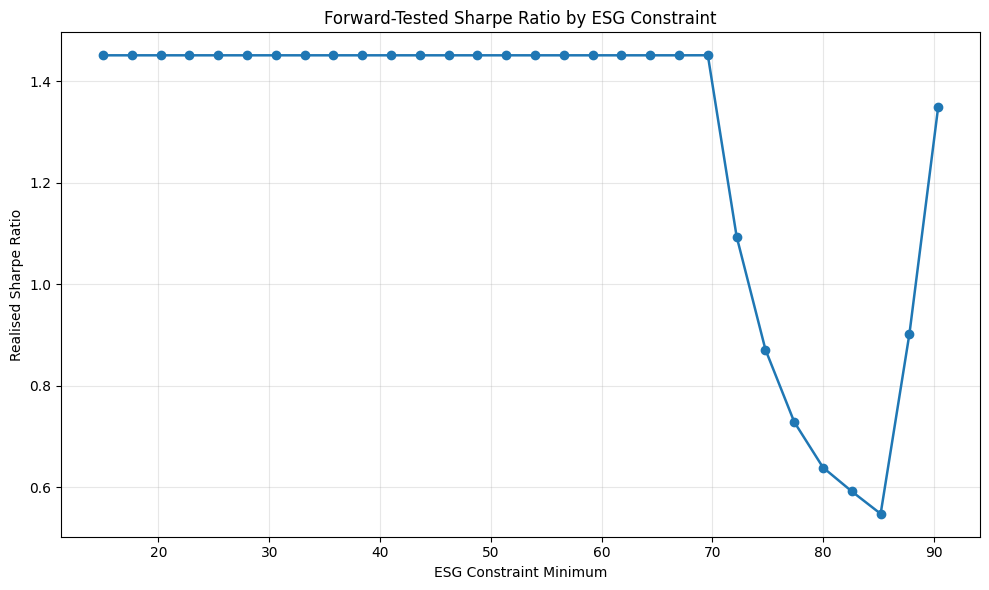

Saved: forward_testing_results/realised_sharpe_by_esg.png


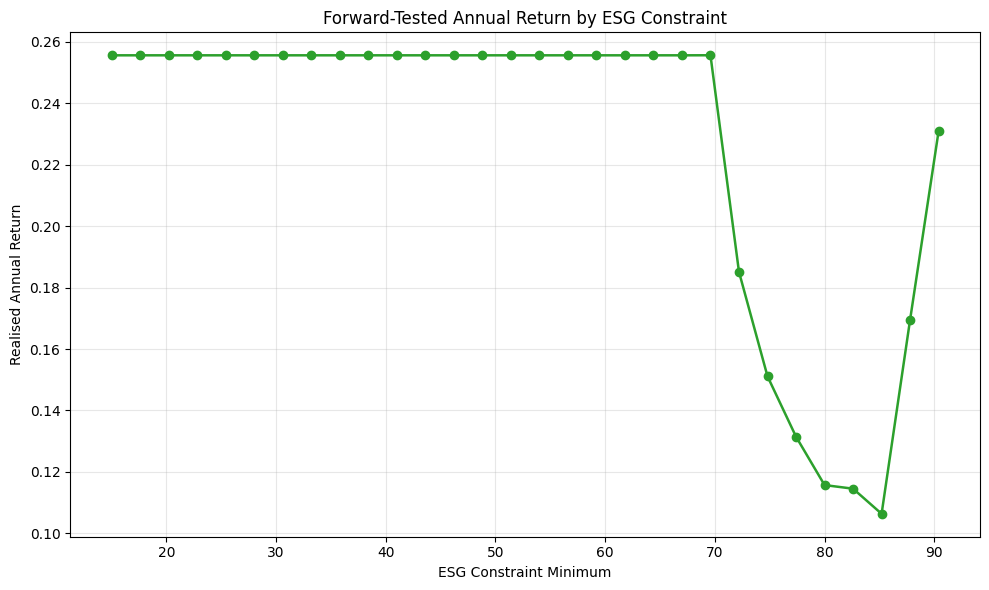

Saved: forward_testing_results/realised_return_by_esg.png


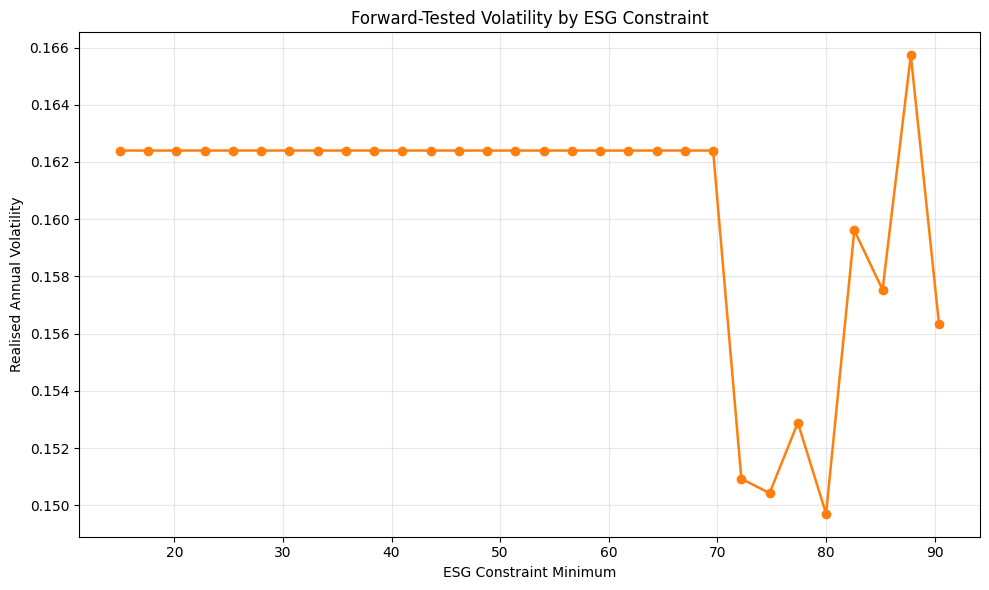

Saved: forward_testing_results/realised_volatility_by_esg.png


In [ ]:
# ============================================================
# Forward testing graphs: realised performance vs ESG constraint
# ============================================================

if forward_test_results.empty:
    raise ValueError("forward_test_results is empty. Run the forward test cell first.")

# Realised Sharpe vs ESG
plt.figure(figsize=(10, 6))
plt.plot(
    forward_test_results["ESG_Min"],
    forward_test_results["Realised_Sharpe"],
    marker="o",
    linewidth=1.8,
    color="tab:blue"
)
plt.xlabel("ESG Constraint Minimum")
plt.ylabel("Realised Sharpe Ratio")
plt.title("Forward-Tested Sharpe Ratio by ESG Constraint")
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = os.path.join(forward_output_dir, "realised_sharpe_by_esg.png")
plt.savefig(out_path, dpi=300)
plt.show()
print(f"Saved: {out_path}")


# Realised annual return vs ESG
plt.figure(figsize=(10, 6))
plt.plot(
    forward_test_results["ESG_Min"],
    forward_test_results["Realised_Annual_Return"],
    marker="o",
    linewidth=1.8,
    color="tab:green"
)
plt.xlabel("ESG Constraint Minimum")
plt.ylabel("Realised Annual Return")
plt.title("Forward-Tested Annual Return by ESG Constraint")
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = os.path.join(forward_output_dir, "realised_return_by_esg.png")
plt.savefig(out_path, dpi=300)
plt.show()
print(f"Saved: {out_path}")


# Realised volatility vs ESG
plt.figure(figsize=(10, 6))
plt.plot(
    forward_test_results["ESG_Min"],
    forward_test_results["Realised_Annual_Volatility"],
    marker="o",
    linewidth=1.8,
    color="tab:orange"
)
plt.xlabel("ESG Constraint Minimum")
plt.ylabel("Realised Annual Volatility")
plt.title("Forward-Tested Volatility by ESG Constraint")
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = os.path.join(forward_output_dir, "realised_volatility_by_esg.png")
plt.savefig(out_path, dpi=300)
plt.show()
print(f"Saved: {out_path}")


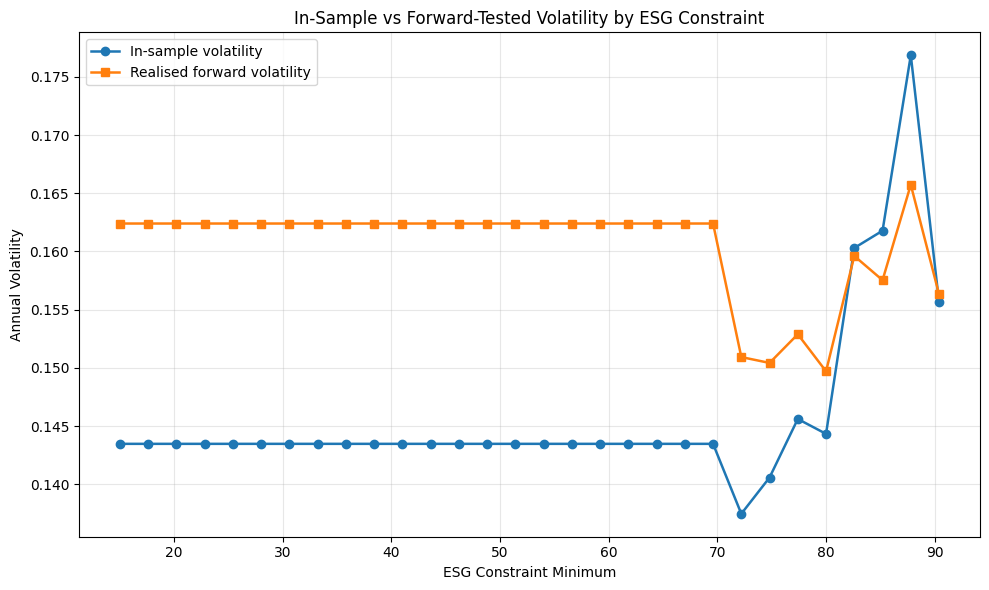

Saved: forward_testing_results/in_sample_vs_realised_volatility_by_esg.png


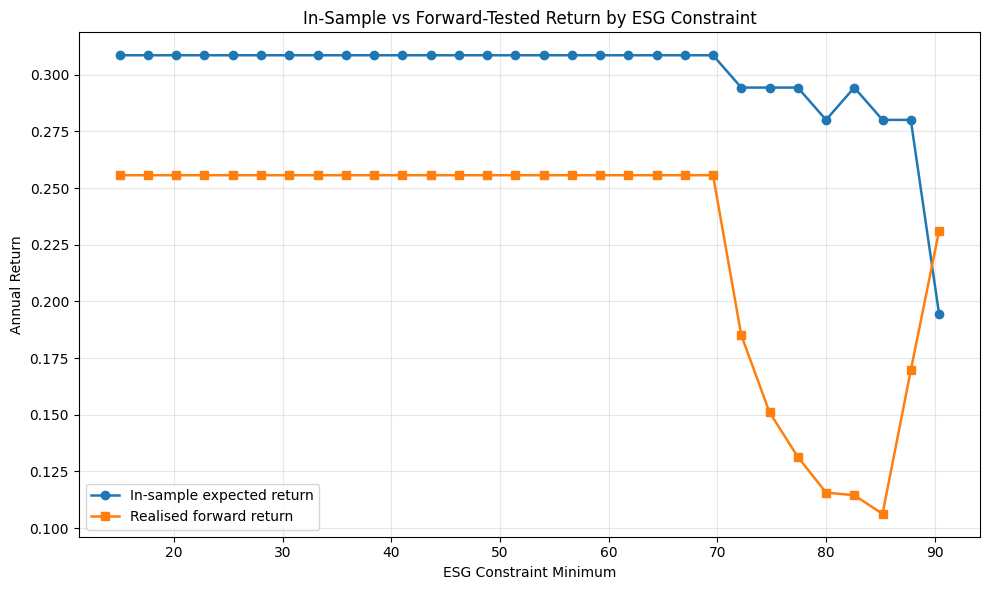

Saved: forward_testing_results/in_sample_vs_realised_return_by_esg.png


In [ ]:
# ============================================================
# Plot in-sample vs realised return and volatility
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

forward_output_dir = "forward_testing_results"

results_path = os.path.join(
    forward_output_dir,
    "max_sharpe_forward_test_results.csv"
)

forward_test_results = pd.read_csv(results_path)


# ============================================================
# In-sample volatility vs realised volatility
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    forward_test_results["ESG_Min"],
    forward_test_results["In_Sample_Volatility"],
    marker="o",
    linewidth=1.8,
    label="In-sample volatility"
)

plt.plot(
    forward_test_results["ESG_Min"],
    forward_test_results["Realised_Annual_Volatility"],
    marker="s",
    linewidth=1.8,
    label="Realised forward volatility"
)

plt.xlabel("ESG Constraint Minimum")
plt.ylabel("Annual Volatility")
plt.title("In-Sample vs Forward-Tested Volatility by ESG Constraint")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = os.path.join(
    forward_output_dir,
    "in_sample_vs_realised_volatility_by_esg.png"
)

plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


# ============================================================
# In-sample return vs realised return
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    forward_test_results["ESG_Min"],
    forward_test_results["In_Sample_Return"],
    marker="o",
    linewidth=1.8,
    label="In-sample expected return"
)

plt.plot(
    forward_test_results["ESG_Min"],
    forward_test_results["Realised_Annual_Return"],
    marker="s",
    linewidth=1.8,
    label="Realised forward return"
)

plt.xlabel("ESG Constraint Minimum")
plt.ylabel("Annual Return")
plt.title("In-Sample vs Forward-Tested Return by ESG Constraint")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = os.path.join(
    forward_output_dir,
    "in_sample_vs_realised_return_by_esg.png"
)

plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


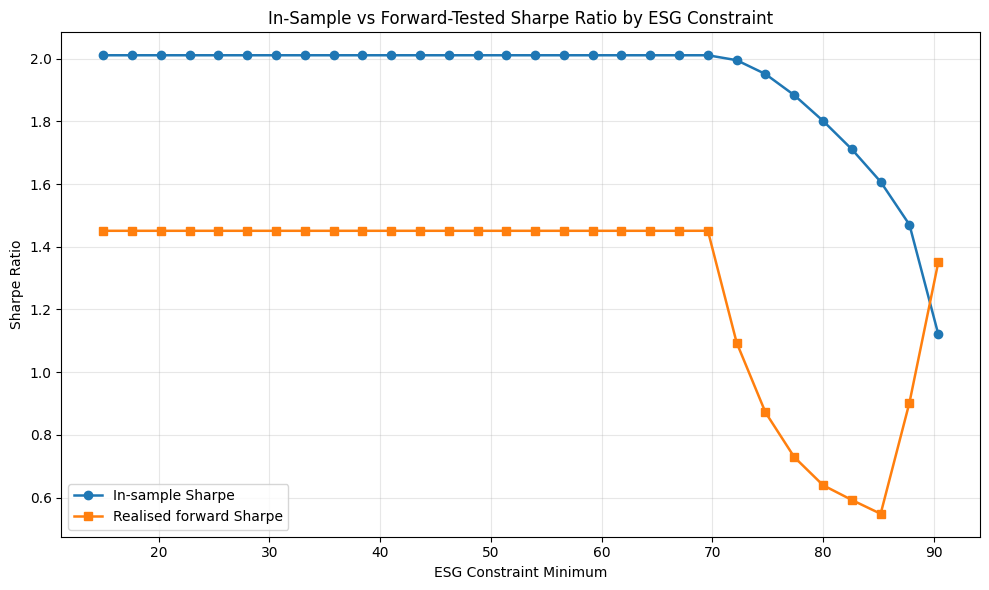

Saved: forward_testing_results/in_sample_vs_realised_sharpe_by_esg.png


In [ ]:
# ============================================================
# Plot in-sample Sharpe vs realised forward Sharpe
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

forward_output_dir = "forward_testing_results"

results_path = os.path.join(
    forward_output_dir,
    "max_sharpe_forward_test_results.csv"
)

forward_test_results = pd.read_csv(results_path)

plt.figure(figsize=(10, 6))

plt.plot(
    forward_test_results["ESG_Min"],
    forward_test_results["In_Sample_Sharpe"],
    marker="o",
    linewidth=1.8,
    label="In-sample Sharpe"
)

plt.plot(
    forward_test_results["ESG_Min"],
    forward_test_results["Realised_Sharpe"],
    marker="s",
    linewidth=1.8,
    label="Realised forward Sharpe"
)

plt.xlabel("ESG Constraint Minimum")
plt.ylabel("Sharpe Ratio")
plt.title("In-Sample vs Forward-Tested Sharpe Ratio by ESG Constraint")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = os.path.join(
    forward_output_dir,
    "in_sample_vs_realised_sharpe_by_esg.png"
)

plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


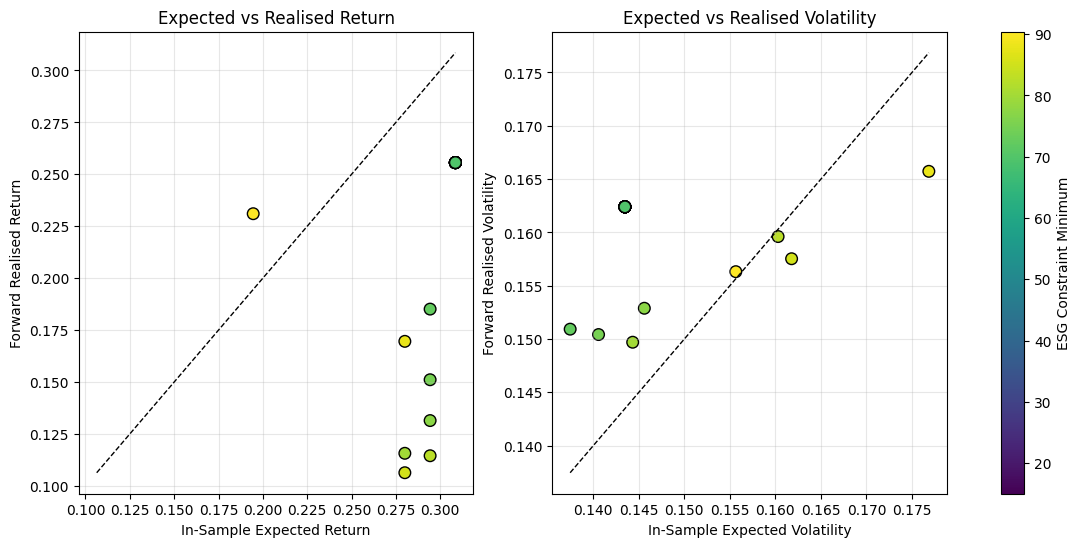

Saved: forward_testing_results/expected_vs_realised_return_volatility.png


In [ ]:
# ============================================================
# Compare in-sample expected performance vs forward rea lised performance
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    forward_test_results["In_Sample_Return"],
    forward_test_results["Realised_Annual_Return"],
    c=forward_test_results["ESG_Min"],
    cmap="viridis",
    s=70,
    edgecolor="black"
)

min_return = min(
    forward_test_results["In_Sample_Return"].min(),
    forward_test_results["Realised_Annual_Return"].min()
)
max_return = max(
    forward_test_results["In_Sample_Return"].max(),
    forward_test_results["Realised_Annual_Return"].max()
)

axes[0].plot(
    [min_return, max_return],
    [min_return, max_return],
    linestyle="--",
    color="black",
    linewidth=1
)

axes[0].set_xlabel("In-Sample Expected Return")
axes[0].set_ylabel("Forward Realised Return")
axes[0].set_title("Expected vs Realised Return")
axes[0].grid(True, alpha=0.3)


scatter = axes[1].scatter(
    forward_test_results["In_Sample_Volatility"],
    forward_test_results["Realised_Annual_Volatility"],
    c=forward_test_results["ESG_Min"],
    cmap="viridis",
    s=70,
    edgecolor="black"
)

min_vol = min(
    forward_test_results["In_Sample_Volatility"].min(),
    forward_test_results["Realised_Annual_Volatility"].min()
)
max_vol = max(
    forward_test_results["In_Sample_Volatility"].max(),
    forward_test_results["Realised_Annual_Volatility"].max()
)

axes[1].plot(
    [min_vol, max_vol],
    [min_vol, max_vol],
    linestyle="--",
    color="black",
    linewidth=1
)

axes[1].set_xlabel("In-Sample Expected Volatility")
axes[1].set_ylabel("Forward Realised Volatility")
axes[1].set_title("Expected vs Realised Volatility")
axes[1].grid(True, alpha=0.3)

cbar = fig.colorbar(scatter, ax=axes)
cbar.set_label("ESG Constraint Minimum")

out_path = os.path.join(
    forward_output_dir,
    "expected_vs_realised_return_volatility.png"
)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")


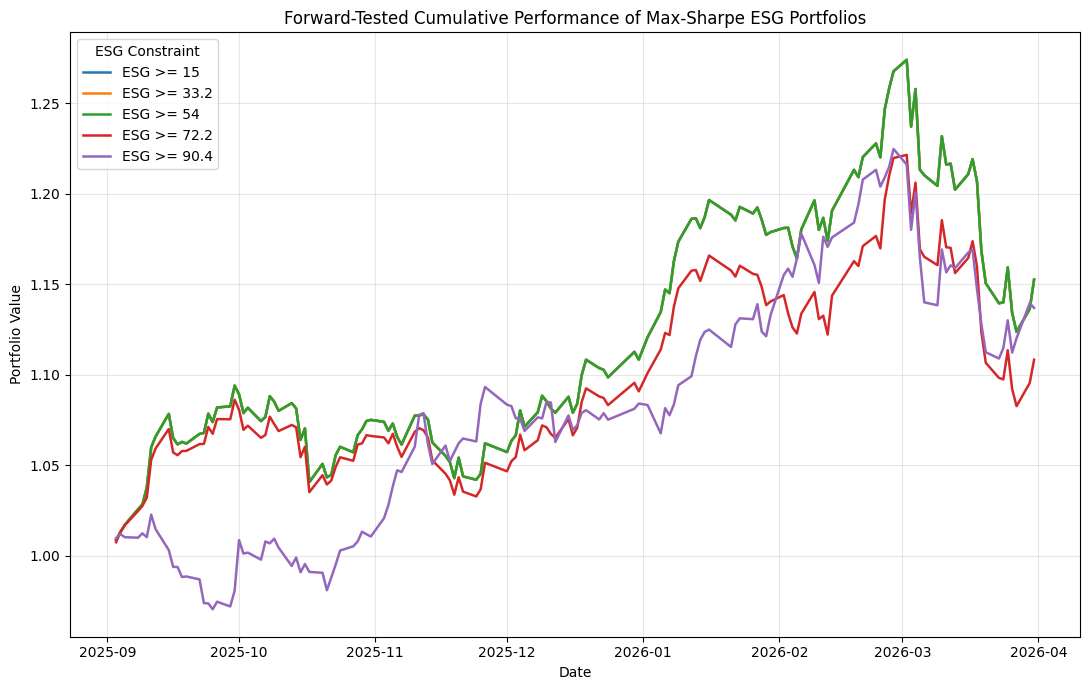

Saved: forward_testing_results/cumulative_forward_performance_selected_esg.png


In [ ]:
# ============================================================
# Cumulative forward performance for selected ESG constraints
# ============================================================

if forward_portfolio_daily_returns.empty:
    raise ValueError("No forward portfolio daily returns found.")

esg_levels = sorted(forward_test_results["ESG_Min"].unique())

selected_esg_levels = [
    min(esg_levels),
    esg_levels[len(esg_levels) // 4],
    esg_levels[len(esg_levels) // 2],
    esg_levels[3 * len(esg_levels) // 4],
    max(esg_levels)
]

plt.figure(figsize=(11, 7))

for esg_min in selected_esg_levels:
    col_name = f"ESG_{esg_min:g}"

    if col_name not in forward_portfolio_daily_returns.columns:
        continue

    cumulative_value = np.exp(forward_portfolio_daily_returns[col_name].cumsum())

    plt.plot(
        cumulative_value.index,
        cumulative_value.values,
        linewidth=1.8,
        label=f"ESG >= {esg_min:g}"
    )

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.title("Forward-Tested Cumulative Performance of Max-Sharpe ESG Portfolios")
plt.grid(True, alpha=0.3)
plt.legend(title="ESG Constraint")
plt.tight_layout()

out_path = os.path.join(
    forward_output_dir,
    "cumulative_forward_performance_selected_esg.png"
)
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


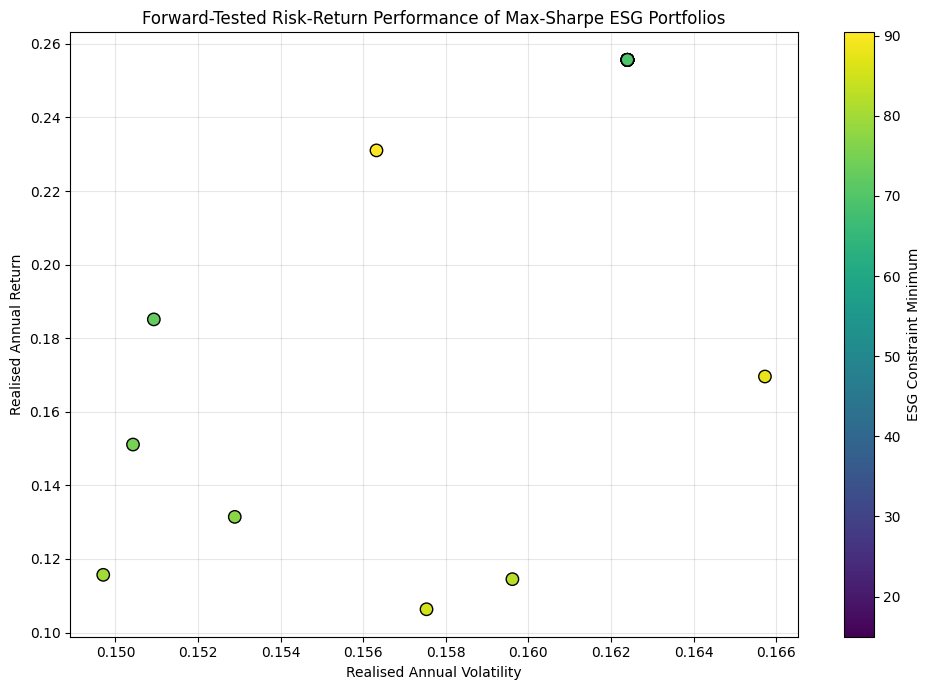

Saved: forward_testing_results/forward_realised_risk_return.png


In [ ]:
# ============================================================
# Forward-tested realised risk-return plot
# ============================================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    forward_test_results["Realised_Annual_Volatility"],
    forward_test_results["Realised_Annual_Return"],
    c=forward_test_results["ESG_Min"],
    cmap="viridis",
    s=80,
    edgecolor="black"
)

plt.xlabel("Realised Annual Volatility")
plt.ylabel("Realised Annual Return")
plt.title("Forward-Tested Risk-Return Performance of Max-Sharpe ESG Portfolios")
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label("ESG Constraint Minimum")

plt.tight_layout()

out_path = os.path.join(
    forward_output_dir,
    "forward_realised_risk_return.png"
)
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


forwards testing all the portfolios created

In [ ]:
# ============================================================
# Forward test all portfolios across all ESG efficient frontiers
# ============================================================

import os
import glob
import numpy as np
import pandas as pd

frontier_dir = "results_frontiers"
forward_all_output_dir = "forward_testing_all_results"

os.makedirs(forward_all_output_dir, exist_ok=True)

rf = 0.02
trading_days = 252


def _normalize_forward_asset_name(name):
    name = str(name).strip().upper()

    for suffix in ["_H", "_E", "_N"]:
        if name.endswith(suffix):
            name = name[:-2]

    name = name.rstrip(".")
    return name


def max_drawdown_from_log_returns(log_returns):
    cumulative_value = np.exp(log_returns.cumsum())
    running_max = cumulative_value.cummax()
    drawdown = cumulative_value / running_max - 1
    return float(drawdown.min())


def realised_forward_stats(portfolio_log_returns, rf=0.02):
    annual_return = float(portfolio_log_returns.mean() * trading_days)
    annual_volatility = float(portfolio_log_returns.std(ddof=1) * np.sqrt(trading_days))

    if annual_volatility > 0:
        sharpe = float((annual_return - rf) / annual_volatility)
    else:
        sharpe = np.nan

    cumulative_return = float(np.exp(portfolio_log_returns.sum()) - 1)
    max_drawdown = max_drawdown_from_log_returns(portfolio_log_returns)

    return annual_return, annual_volatility, sharpe, cumulative_return, max_drawdown


def concentration_metrics_from_weights(weights):
    hhi = float(np.sum(weights ** 2))
    effective_holdings = float(1 / hhi) if hhi > 0 else np.nan
    max_weight = float(np.max(weights)) if len(weights) > 0 else np.nan
    return hhi, effective_holdings, max_weight


frontier_csvs = sorted(
    glob.glob(os.path.join(frontier_dir, "esg_constraint_*_frontier_weights.csv"))
)

if len(frontier_csvs) == 0:
    raise ValueError("No ESG frontier CSV files found. Run the optimisation cell first.")

if "forward_returns" not in globals():
    raise ValueError("forward_returns not found. Run the forward returns cell first.")

all_forward_rows = []
all_daily_returns = []

for csv_path in frontier_csvs:
    df = pd.read_csv(csv_path)

    if "Volatility" not in df.columns or "Return" not in df.columns:
        continue

    esg_min = float(os.path.basename(csv_path).split("_")[-3])

    asset_cols = [c for c in df.columns if c not in ["Volatility", "Return"]]

    for frontier_point, row in df.reset_index(drop=True).iterrows():

        original_weights = row[asset_cols].astype(float)
        original_weights.index = [
            _normalize_forward_asset_name(ticker)
            for ticker in original_weights.index
        ]

        # Combine duplicate tickers after normalisation, if any
        original_weights = original_weights.groupby(original_weights.index).sum()

        original_nonzero_holdings = int((original_weights > 1e-8).sum())

        matched_assets = [
            ticker for ticker in original_weights.index
            if ticker in forward_returns.columns
        ]

        missing_assets = [
            ticker for ticker in original_weights.index
            if ticker not in forward_returns.columns and original_weights.loc[ticker] > 1e-8
        ]

        matched_weights = original_weights.loc[matched_assets].copy()
        weight_coverage = float(matched_weights.sum())

        if weight_coverage <= 0:
            continue

        # Renormalise after dropping missing assets
        matched_weights = matched_weights / matched_weights.sum()

        matched_forward_returns = forward_returns[matched_weights.index]
        portfolio_forward_returns = matched_forward_returns @ matched_weights.values

        portfolio_id = f"ESG_{esg_min:g}_Point_{frontier_point:03d}"
        portfolio_forward_returns.name = portfolio_id

        (
            realised_return,
            realised_volatility,
            realised_sharpe,
            cumulative_return,
            max_drawdown
        ) = realised_forward_stats(portfolio_forward_returns, rf=rf)

        hhi, effective_holdings, max_weight = concentration_metrics_from_weights(
            matched_weights.values
        )

        in_sample_return = float(row["Return"])
        in_sample_volatility = float(row["Volatility"])
        in_sample_sharpe = (
            (in_sample_return - rf) / in_sample_volatility
            if in_sample_volatility > 0 else np.nan
        )

        all_forward_rows.append({
            "Portfolio_ID": portfolio_id,
            "ESG_Min": esg_min,
            "Frontier_Point": frontier_point,

            "In_Sample_Return": in_sample_return,
            "In_Sample_Volatility": in_sample_volatility,
            "In_Sample_Sharpe": in_sample_sharpe,

            "Realised_Annual_Return": realised_return,
            "Realised_Annual_Volatility": realised_volatility,
            "Realised_Sharpe": realised_sharpe,
            "Cumulative_Return": cumulative_return,
            "Max_Drawdown": max_drawdown,

            "Original_Nonzero_Holdings": original_nonzero_holdings,
            "Matched_Assets": len(matched_assets),
            "Missing_Nonzero_Assets": len(missing_assets),
            "Weight_Coverage_Before_Renormalising": weight_coverage,

            "Forward_HHI": hhi,
            "Forward_Effective_Holdings": effective_holdings,
            "Forward_Max_Weight": max_weight,

            "Missing_Assets": ", ".join(missing_assets)
        })

        all_daily_returns.append(portfolio_forward_returns)

all_forward_results = (
    pd.DataFrame(all_forward_rows)
    .sort_values(["ESG_Min", "Frontier_Point"])
    .reset_index(drop=True)
)

all_results_path = os.path.join(
    forward_all_output_dir,
    "all_frontiers_forward_test_results.csv"
)
all_forward_results.to_csv(all_results_path, index=False)

all_daily_returns_df = pd.concat(all_daily_returns, axis=1)

all_daily_returns_path = os.path.join(
    forward_all_output_dir,
    "all_frontiers_forward_daily_returns.csv"
)
all_daily_returns_df.to_csv(all_daily_returns_path)

print(f"Forward-tested portfolios: {len(all_forward_results)}")
print(f"Saved all frontier forward results to: {all_results_path}")
print(f"Saved all frontier daily returns to: {all_daily_returns_path}")

display(all_forward_results.head())


Forward-tested portfolios: 1672
Saved all frontier forward results to: forward_testing_all_results/all_frontiers_forward_test_results.csv
Saved all frontier daily returns to: forward_testing_all_results/all_frontiers_forward_daily_returns.csv


,Portfolio_ID,ESG_Min,Frontier_Point,In_Sample_Return,In_Sample_Volatility,In_Sample_Sharpe,Realised_Annual_Return,Realised_Annual_Volatility,Realised_Sharpe,Cumulative_Return,Max_Drawdown,Original_Nonzero_Holdings,Matched_Assets,Missing_Nonzero_Assets,Weight_Coverage_Before_Renormalising,Forward_HHI,Forward_Effective_Holdings,Forward_Max_Weight,Missing_Assets
0,ESG_15_Point_000,15.0,0,-0.318355,0.282449,-1.197933,0.319854,0.323439,0.927081,0.194463,-0.216065,1,97,0,1.0,1.000000,1.000000,1.000000,
1,ESG_15_Point_001,15.0,1,-0.304108,0.258444,-1.254072,0.242190,0.290738,0.764230,0.144022,-0.222632,3,97,0,1.0,0.730917,1.368145,0.846594,
2,ESG_15_Point_002,15.0,2,-0.289860,0.238352,-1.300010,0.136304,0.271053,0.429082,0.078665,-0.226878,3,97,0,1.0,0.571512,1.749743,0.731486,
3,ESG_15_Point_003,15.0,3,-0.275612,0.220779,-1.338949,0.030418,0.256945,0.040544,0.017042,-0.231102,3,97,0,1.0,0.461388,2.167371,0.616378,
4,ESG_15_Point_004,15.0,4,-0.261364,0.206371,-1.363393,-0.075469,0.249361,-0.382854,-0.041060,-0.235303,3,97,0,1.0,0.400545,2.496600,0.501270,


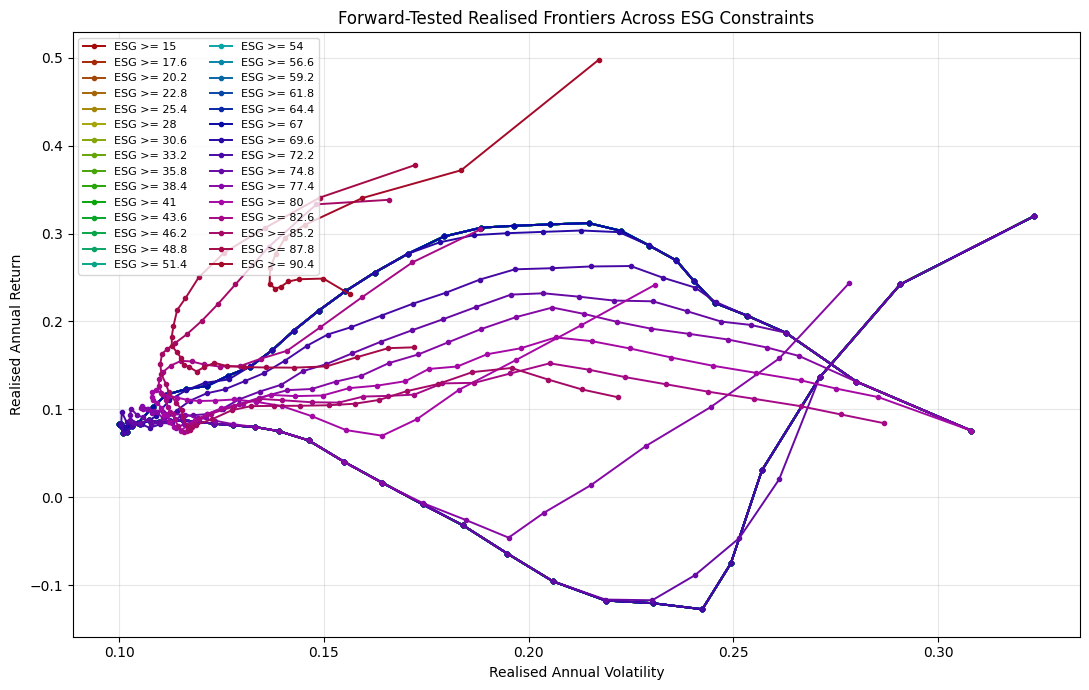

Saved: forward_testing_all_results/all_realised_forward_frontiers.png


In [ ]:
# ============================================================
# Plot realised forward-tested frontiers
# ============================================================

import colorsys
import matplotlib.pyplot as plt

if all_forward_results.empty:
    raise ValueError("all_forward_results is empty. Run the full forward test cell first.")

plt.figure(figsize=(11, 7))

esg_levels = sorted(all_forward_results["ESG_Min"].unique())

n_curves = max(len(esg_levels), 1)
curve_colors = []

for i in range(n_curves):
    hue = i / n_curves
    rgb = colorsys.hls_to_rgb(hue, 0.34, 0.9)
    curve_colors.append(rgb)

for idx, esg_min in enumerate(esg_levels):
    group = (
        all_forward_results[all_forward_results["ESG_Min"] == esg_min]
        .sort_values("In_Sample_Return")
    )

    plt.plot(
        group["Realised_Annual_Volatility"],
        group["Realised_Annual_Return"],
        marker="o",
        markersize=3,
        linewidth=1.4,
        color=curve_colors[idx],
        label=f"ESG >= {esg_min:g}"
    )

plt.xlabel("Realised Annual Volatility")
plt.ylabel("Realised Annual Return")
plt.title("Forward-Tested Realised Frontiers Across ESG Constraints")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

out_path = os.path.join(
    forward_all_output_dir,
    "all_realised_forward_frontiers.png"
)
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


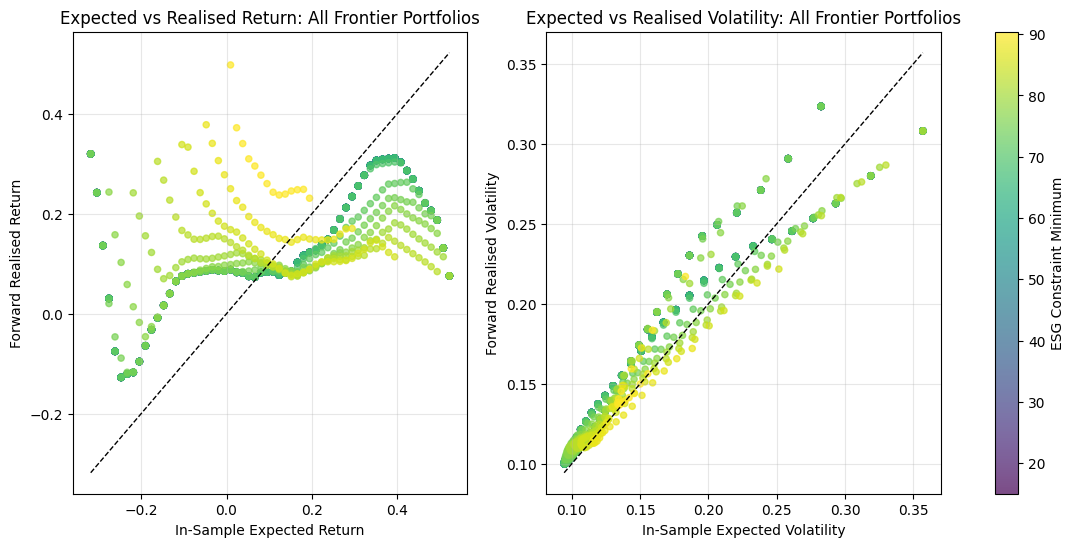

Saved: forward_testing_all_results/all_expected_vs_realised_return_volatility.png


In [ ]:
# ============================================================
# Expected vs realised return and volatility for all frontier portfolios
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter_1 = axes[0].scatter(
    all_forward_results["In_Sample_Return"],
    all_forward_results["Realised_Annual_Return"],
    c=all_forward_results["ESG_Min"],
    cmap="viridis",
    s=20,
    alpha=0.7
)

min_return = min(
    all_forward_results["In_Sample_Return"].min(),
    all_forward_results["Realised_Annual_Return"].min()
)
max_return = max(
    all_forward_results["In_Sample_Return"].max(),
    all_forward_results["Realised_Annual_Return"].max()
)

axes[0].plot(
    [min_return, max_return],
    [min_return, max_return],
    linestyle="--",
    color="black",
    linewidth=1
)

axes[0].set_xlabel("In-Sample Expected Return")
axes[0].set_ylabel("Forward Realised Return")
axes[0].set_title("Expected vs Realised Return: All Frontier Portfolios")
axes[0].grid(True, alpha=0.3)


scatter_2 = axes[1].scatter(
    all_forward_results["In_Sample_Volatility"],
    all_forward_results["Realised_Annual_Volatility"],
    c=all_forward_results["ESG_Min"],
    cmap="viridis",
    s=20,
    alpha=0.7
)

min_vol = min(
    all_forward_results["In_Sample_Volatility"].min(),
    all_forward_results["Realised_Annual_Volatility"].min()
)
max_vol = max(
    all_forward_results["In_Sample_Volatility"].max(),
    all_forward_results["Realised_Annual_Volatility"].max()
)

axes[1].plot(
    [min_vol, max_vol],
    [min_vol, max_vol],
    linestyle="--",
    color="black",
    linewidth=1
)

axes[1].set_xlabel("In-Sample Expected Volatility")
axes[1].set_ylabel("Forward Realised Volatility")
axes[1].set_title("Expected vs Realised Volatility: All Frontier Portfolios")
axes[1].grid(True, alpha=0.3)

cbar = fig.colorbar(scatter_2, ax=axes)
cbar.set_label("ESG Constraint Minimum")

out_path = os.path.join(
    forward_all_output_dir,
    "all_expected_vs_realised_return_volatility.png"
)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")


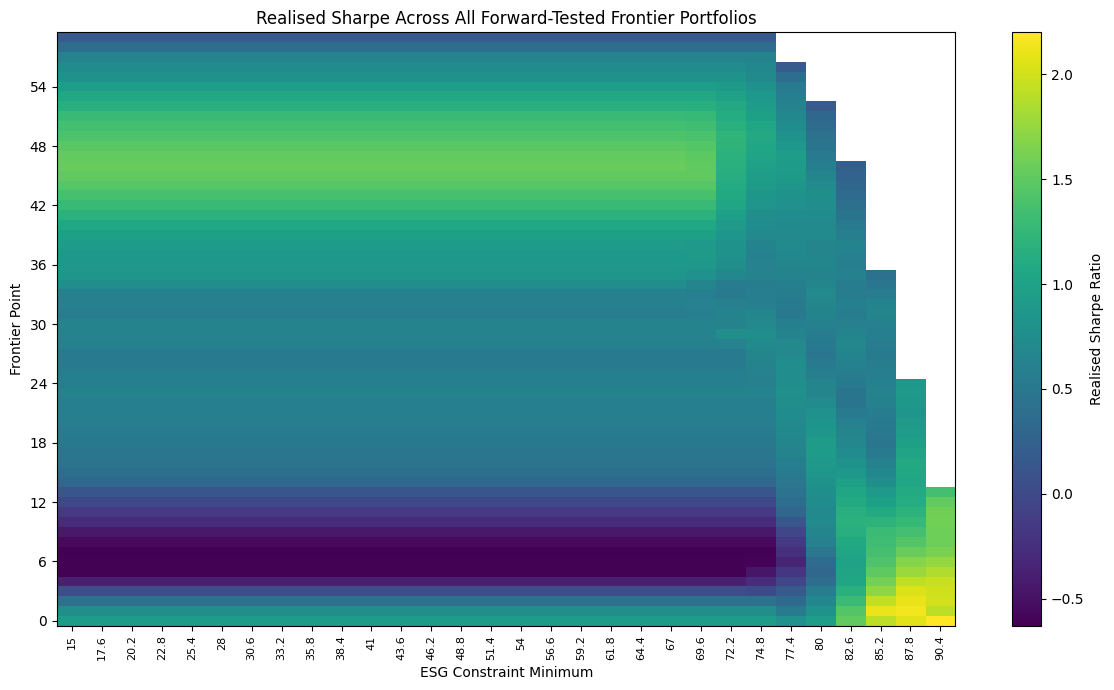

Saved: forward_testing_all_results/realised_sharpe_heatmap_all_frontiers.png


In [ ]:
# ============================================================
# Realised Sharpe heatmap across ESG constraints and frontier points
# ============================================================

sharpe_pivot = all_forward_results.pivot_table(
    index="Frontier_Point",
    columns="ESG_Min",
    values="Realised_Sharpe"
)

plt.figure(figsize=(12, 7))

plt.imshow(
    sharpe_pivot.values,
    aspect="auto",
    origin="lower",
    cmap="viridis"
)

plt.colorbar(label="Realised Sharpe Ratio")

plt.xticks(
    ticks=np.arange(len(sharpe_pivot.columns)),
    labels=[f"{x:g}" for x in sharpe_pivot.columns],
    rotation=90,
    fontsize=8
)

plt.yticks(
    ticks=np.arange(0, len(sharpe_pivot.index), max(1, len(sharpe_pivot.index) // 10)),
    labels=sharpe_pivot.index[::max(1, len(sharpe_pivot.index) // 10)]
)

plt.xlabel("ESG Constraint Minimum")
plt.ylabel("Frontier Point")
plt.title("Realised Sharpe Across All Forward-Tested Frontier Portfolios")
plt.tight_layout()

out_path = os.path.join(
    forward_all_output_dir,
    "realised_sharpe_heatmap_all_frontiers.png"
)
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


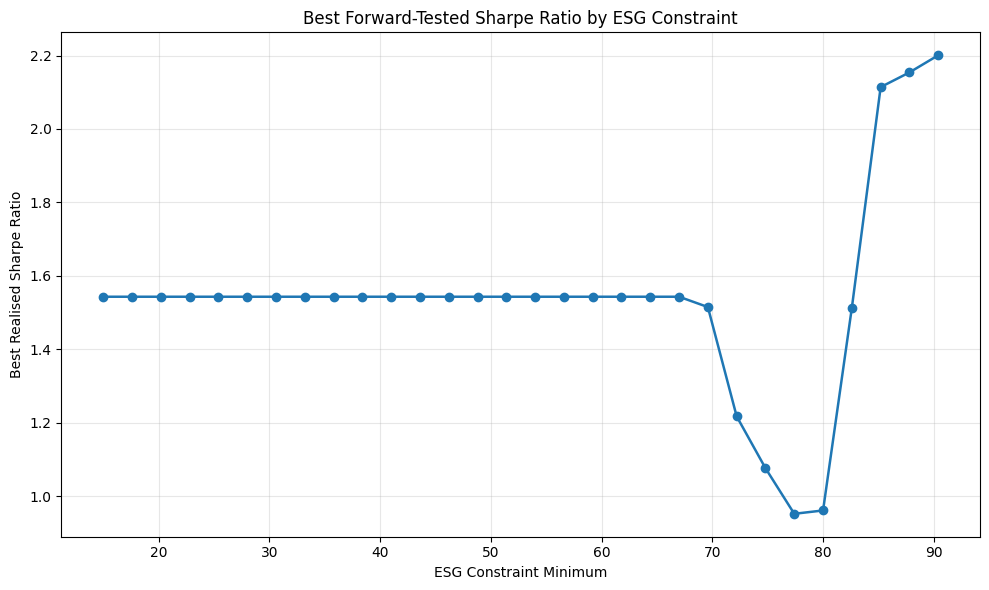

Saved: forward_testing_all_results/best_realised_sharpe_by_esg.csv
Saved: forward_testing_all_results/best_realised_sharpe_by_esg.png


,ESG_Min,Portfolio_ID,Frontier_Point,In_Sample_Return,In_Sample_Volatility,In_Sample_Sharpe,Realised_Annual_Return,Realised_Annual_Volatility,Realised_Sharpe,Cumulative_Return,Max_Drawdown,Original_Nonzero_Holdings,Matched_Assets,Missing_Nonzero_Assets,Weight_Coverage_Before_Renormalising,Forward_HHI,Forward_Effective_Holdings,Forward_Max_Weight,Missing_Assets
0,15.0,ESG_15_Point_046,46,0.337041,0.158682,1.997967,0.296684,0.179323,1.542934,0.179186,-0.125213,8,97,0,1.000000,0.160061,6.247629,0.228481,
1,17.6,ESG_17.6_Point_046,46,0.337041,0.158682,1.997967,0.296684,0.179323,1.542934,0.179186,-0.125213,8,97,0,1.000000,0.160061,6.247629,0.228481,
2,20.2,ESG_20.2_Point_046,46,0.337041,0.158682,1.997967,0.296684,0.179323,1.542934,0.179186,-0.125213,8,97,0,1.000000,0.160061,6.247629,0.228481,
3,22.8,ESG_22.8_Point_046,46,0.337041,0.158682,1.997967,0.296684,0.179323,1.542934,0.179186,-0.125213,8,97,0,1.000000,0.160061,6.247629,0.228481,
4,25.4,ESG_25.4_Point_046,46,0.337041,0.158682,1.997967,0.296684,0.179323,1.542934,0.179186,-0.125213,8,97,0,1.000000,0.160061,6.247629,0.228481,
5,28.0,ESG_28_Point_046,46,0.337041,0.158682,1.997967,0.296684,0.179323,1.542934,0.179186,-0.125213,8,97,0,1.000000,0.160061,6.247629,0.228481,
6,30.6,ESG_30.6_Point_046,46,0.337041,0.158682,1.997967,0.296684,0.179323,1.542934,0.179186,-0.125213,8,97,0,1.000000,0.160061,6.247629,0.228481,
7,33.2,ESG_33.2_Point_046,46,0.337041,0.158682,1.997967,0.296684,0.179323,1.542934,0.179186,-0.125213,8,97,0,1.000000,0.160061,6.247629,0.228481,
8,35.8,ESG_35.8_Point_046,46,0.337041,0.158682,1.997967,0.296684,0.179323,1.542934,0.179186,-0.125213,8,97,0,1.000000,0.160061,6.247629,0.228481,
9,38.4,ESG_38.4_Point_046,46,0.337041,0.158682,1.997967,0.296684,0.179323,1.542934,0.179186,-0.125213,8,97,0,1.000000,0.160061,6.247629,0.228481,


In [ ]:
# ============================================================
# Best realised Sharpe portfolio by ESG constraint
# ============================================================

best_realised_by_esg = (
    all_forward_results
    .sort_values(["ESG_Min", "Realised_Sharpe"], ascending=[True, False])
    .groupby("ESG_Min", as_index=False)
    .first()
)

best_realised_path = os.path.join(
    forward_all_output_dir,
    "best_realised_sharpe_by_esg.csv"
)
best_realised_by_esg.to_csv(best_realised_path, index=False)

plt.figure(figsize=(10, 6))

plt.plot(
    best_realised_by_esg["ESG_Min"],
    best_realised_by_esg["Realised_Sharpe"],
    marker="o",
    linewidth=1.8,
    color="tab:blue"
)

plt.xlabel("ESG Constraint Minimum")
plt.ylabel("Best Realised Sharpe Ratio")
plt.title("Best Forward-Tested Sharpe Ratio by ESG Constraint")
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = os.path.join(
    forward_all_output_dir,
    "best_realised_sharpe_by_esg.png"
)
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {best_realised_path}")
print(f"Saved: {out_path}")

display(best_realised_by_esg)


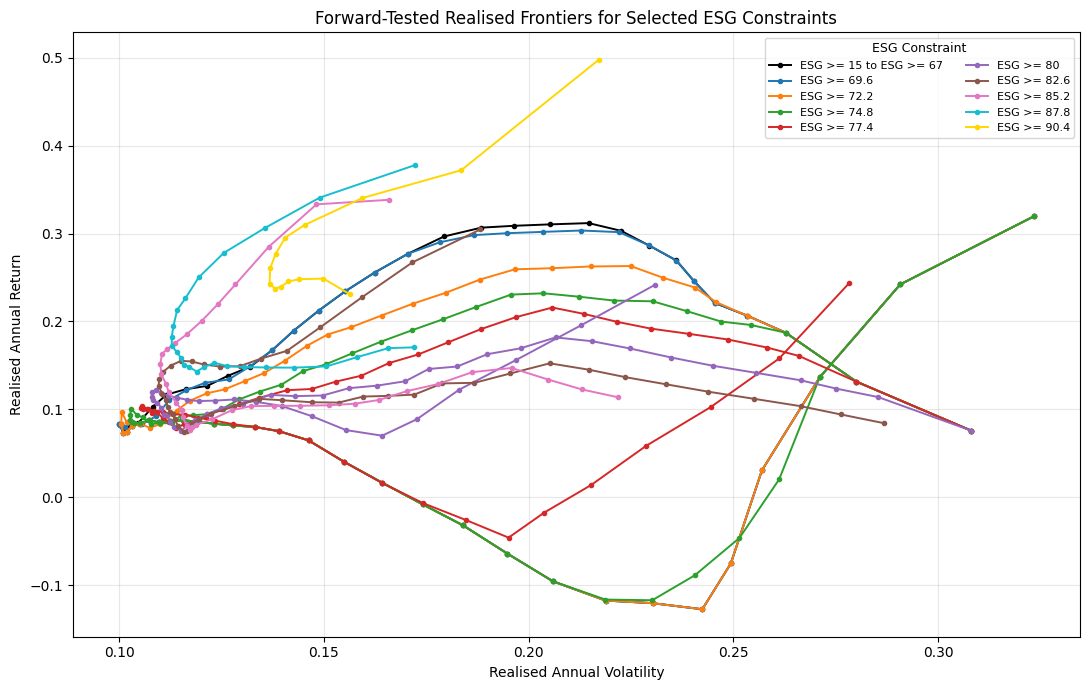

Saved: forward_testing_all_results/selected_realised_forward_frontiers_grouped_esg.png


In [ ]:
# ============================================================
# Plot selected realised forward-tested frontiers
# Group ESG >= 15 to ESG >= 67 together
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

forward_all_dir = "forward_testing_all_results"

results_path = os.path.join(
    forward_all_dir,
    "all_frontiers_forward_test_results.csv"
)

df = pd.read_csv(results_path)

esg_levels_to_plot = [15.0, 69.6, 72.2, 74.8, 77.4, 80.0, 82.6, 85.2, 87.8, 90.4]

labels = {
    15.0: "ESG >= 15 to ESG >= 67",
    69.6: "ESG >= 69.6",
    72.2: "ESG >= 72.2",
    74.8: "ESG >= 74.8",
    77.4: "ESG >= 77.4",
    80.0: "ESG >= 80",
    82.6: "ESG >= 82.6",
    85.2: "ESG >= 85.2",
    87.8: "ESG >= 87.8",
    90.4: "ESG >= 90.4",
}

colors = {
    15.0: "black",
    69.6: "tab:blue",
    72.2: "tab:orange",
    74.8: "tab:green",
    77.4: "tab:red",
    80.0: "tab:purple",
    82.6: "tab:brown",
    85.2: "tab:pink",
    87.8: "tab:cyan",
    90.4: "gold",
}

plt.figure(figsize=(11, 7))

for esg_min in esg_levels_to_plot:
    group = (
        df[df["ESG_Min"] == esg_min]
        .sort_values("In_Sample_Return")
        .reset_index(drop=True)
    )

    if group.empty:
        print(f"No forward-tested results found for ESG >= {esg_min:g}.")
        continue

    plt.plot(
        group["Realised_Annual_Volatility"],
        group["Realised_Annual_Return"],
        marker="o",
        markersize=3,
        linewidth=1.4,
        color=colors[esg_min],
        label=labels[esg_min]
    )

plt.xlabel("Realised Annual Volatility")
plt.ylabel("Realised Annual Return")
plt.title("Forward-Tested Realised Frontiers for Selected ESG Constraints")
plt.grid(True, alpha=0.3)

plt.legend(
    ncol=2,
    fontsize=8,
    title="ESG Constraint",
    title_fontsize=9
)

plt.tight_layout()

out_path = os.path.join(
    forward_all_dir,
    "selected_realised_forward_frontiers_grouped_esg.png"
)

plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")



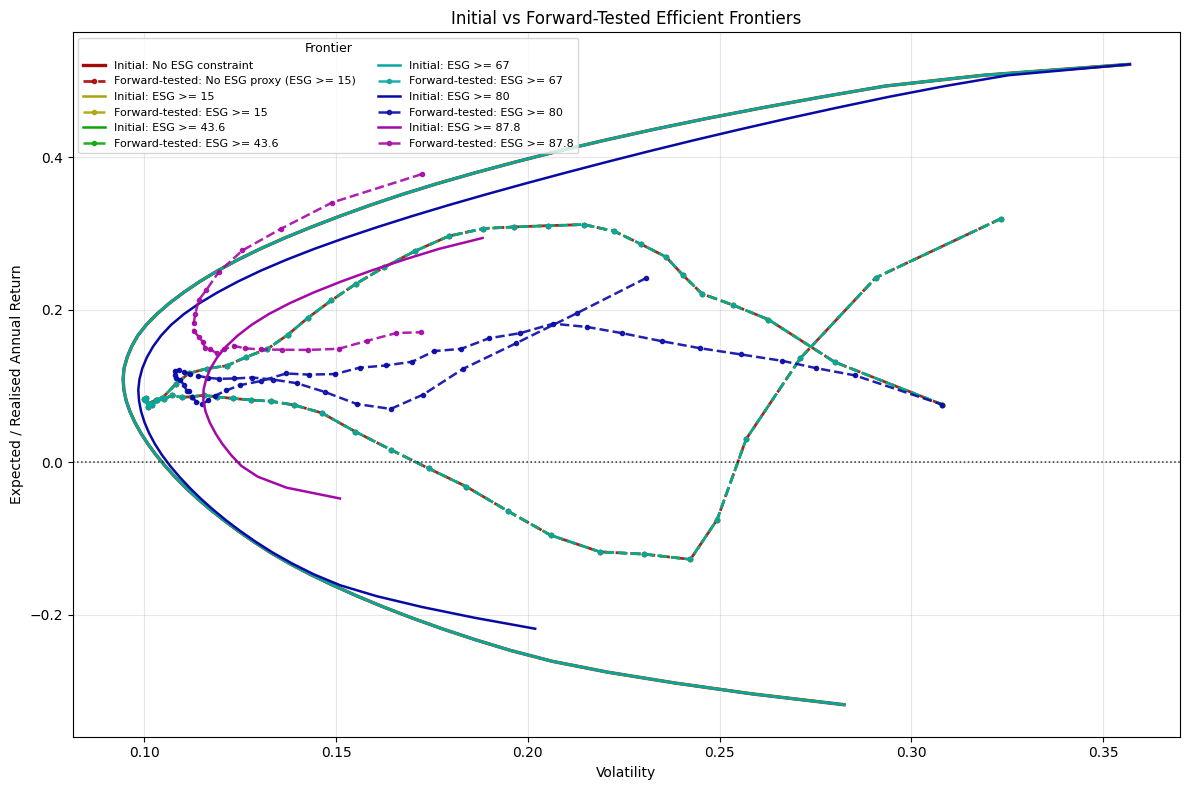

Saved: forward_testing_all_results/initial_vs_forward_tested_selected_frontiers.png


In [26]:
# ============================================================
# Plot Initial vs Forward-Tested Efficient Frontiers
# Selected ESG constraints + No ESG baseline
# ============================================================

import os
import colorsys
import pandas as pd
import matplotlib.pyplot as plt

initial_dir = "results_frontiers"
forward_dir = "forward_testing_all_results"

forward_results_path = os.path.join(
    forward_dir,
    "all_frontiers_forward_test_results.csv"
)

selected_esg_levels = [15.0, 43.6, 67.0, 80.0, 87.8]

# Set to True if you want ESG >= 15 to act as the closest forward-tested proxy
# for the no-ESG frontier.
use_esg15_as_no_esg_forward_proxy = True

forward_df = pd.read_csv(forward_results_path)

plt.figure(figsize=(12, 8))

# ------------------------------------------------------------
# Colours
# ------------------------------------------------------------

labels_for_colours = ["No ESG constraint"] + [f"ESG >= {x:g}" for x in selected_esg_levels]
n_curves = len(labels_for_colours)

curve_colors = {}
for i, label in enumerate(labels_for_colours):
    hue = i / max(n_curves, 1)
    curve_colors[label] = colorsys.hls_to_rgb(hue, 0.34, 0.9)

# ------------------------------------------------------------
# 1) Initial no-ESG frontier
# ------------------------------------------------------------

baseline_path = os.path.join(initial_dir, "baseline_frontier.csv")
baseline_df = pd.read_csv(baseline_path).sort_values("Return")

plt.plot(
    baseline_df["Volatility"],
    baseline_df["Return"],
    color=curve_colors["No ESG constraint"],
    linewidth=2.4,
    linestyle="-",
    label="Initial: No ESG constraint"
)

# Optional realised proxy for no ESG using ESG >= 15
if use_esg15_as_no_esg_forward_proxy:
    no_esg_proxy = (
        forward_df[forward_df["ESG_Min"] == 15.0]
        .sort_values("In_Sample_Return")
    )

    plt.plot(
        no_esg_proxy["Realised_Annual_Volatility"],
        no_esg_proxy["Realised_Annual_Return"],
        color=curve_colors["No ESG constraint"],
        linewidth=2.0,
        linestyle="--",
        marker="o",
        markersize=3,
        alpha=0.9,
        label="Forward-tested: No ESG proxy (ESG >= 15)"
    )

# ------------------------------------------------------------
# 2) Initial and forward-tested ESG frontiers
# ------------------------------------------------------------

for esg_min in selected_esg_levels:
    label = f"ESG >= {esg_min:g}"
    color = curve_colors[label]

    esg_tag = f"{esg_min:g}"
    initial_path = os.path.join(
        initial_dir,
        f"esg_constraint_{esg_tag}_frontier_weights.csv"
    )

    initial_df = pd.read_csv(initial_path).sort_values("Return")

    plt.plot(
        initial_df["Volatility"],
        initial_df["Return"],
        color=color,
        linewidth=1.8,
        linestyle="-",
        label=f"Initial: {label}"
    )

    realised_group = (
        forward_df[forward_df["ESG_Min"] == esg_min]
        .sort_values("In_Sample_Return")
    )

    plt.plot(
        realised_group["Realised_Annual_Volatility"],
        realised_group["Realised_Annual_Return"],
        color=color,
        linewidth=1.8,
        linestyle="--",
        marker="o",
        markersize=3,
        alpha=0.9,
        label=f"Forward-tested: {label}"
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.xlabel("Volatility")
plt.ylabel("Expected / Realised Annual Return")
plt.title("Initial vs Forward-Tested Efficient Frontiers")
plt.grid(True, alpha=0.3)

plt.axhline(
    0.0,
    color="black",
    linestyle=":",
    linewidth=1.1,
    alpha=0.8
)

plt.legend(
    ncol=2,
    fontsize=8,
    title="Frontier",
    title_fontsize=9
)

plt.tight_layout()

out_path = os.path.join(
    forward_dir,
    "initial_vs_forward_tested_selected_frontiers.png"
)

plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")

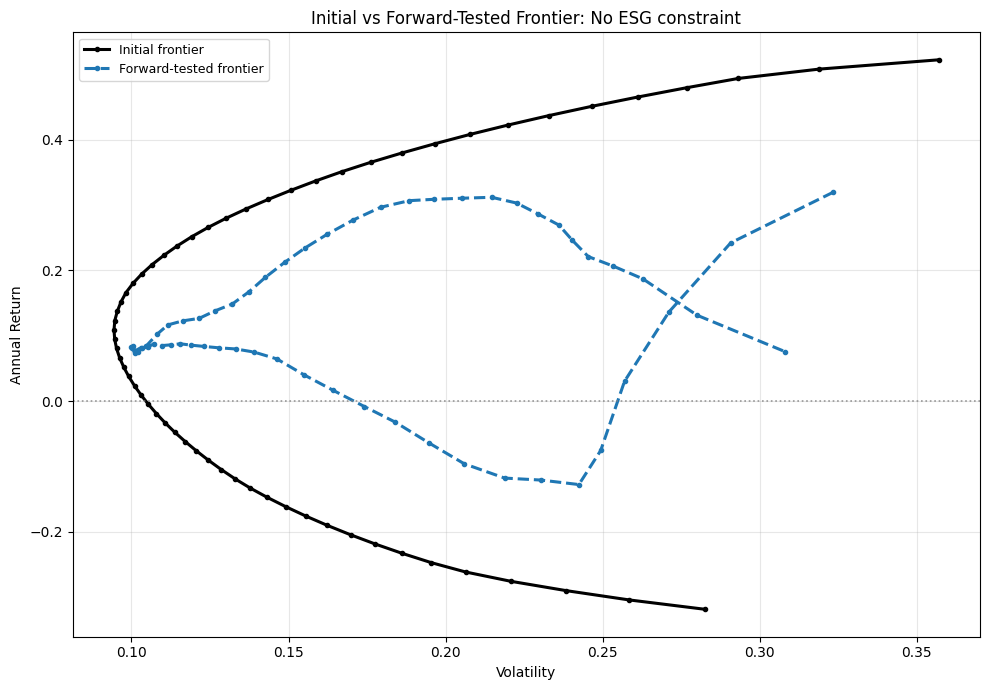

Saved: forward_testing_all_results/initial_vs_forward_no_esg.png


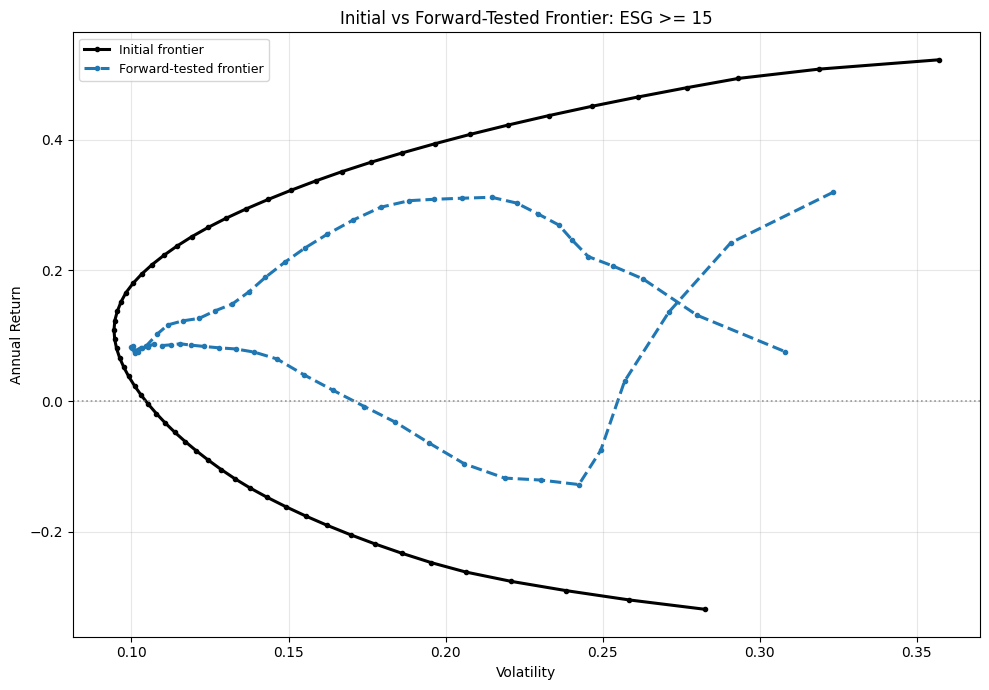

Saved: forward_testing_all_results/initial_vs_forward_esg_15.png


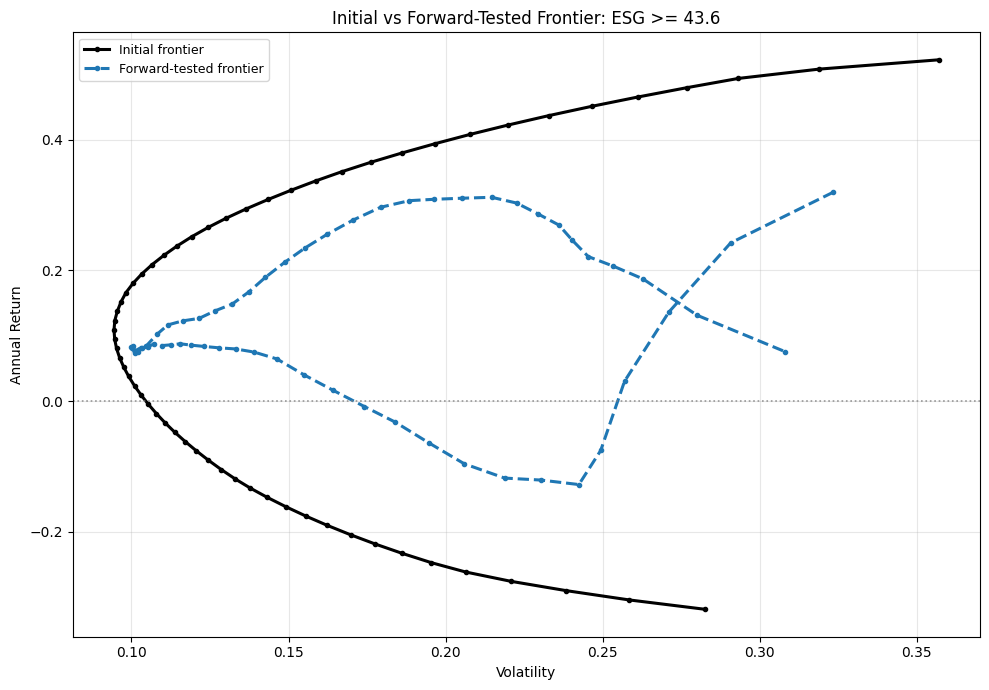

Saved: forward_testing_all_results/initial_vs_forward_esg_43_6.png


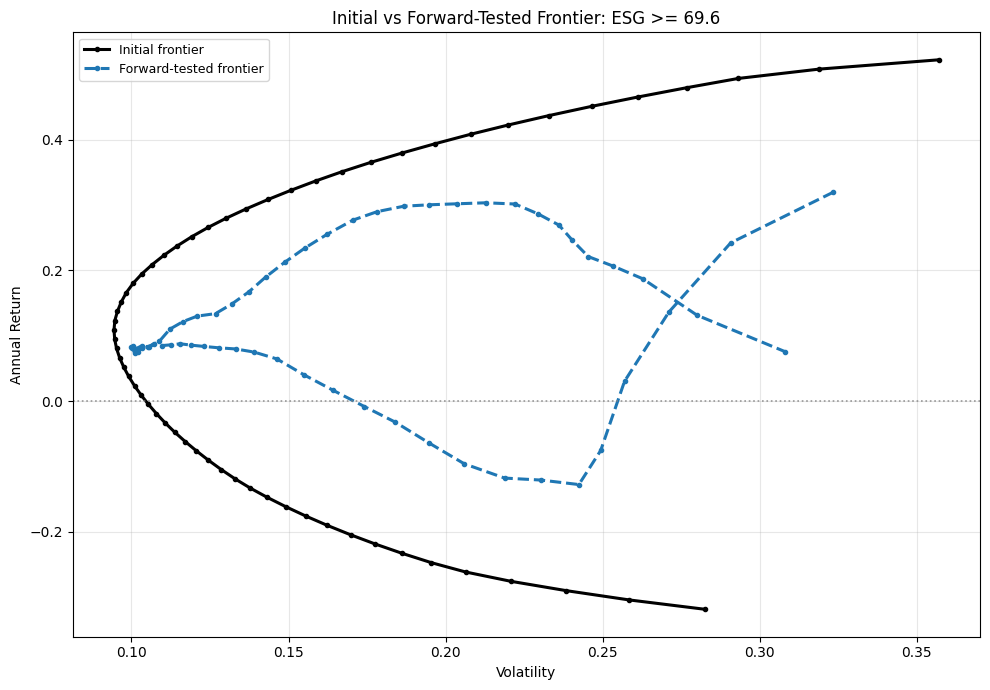

Saved: forward_testing_all_results/initial_vs_forward_esg_69_6.png


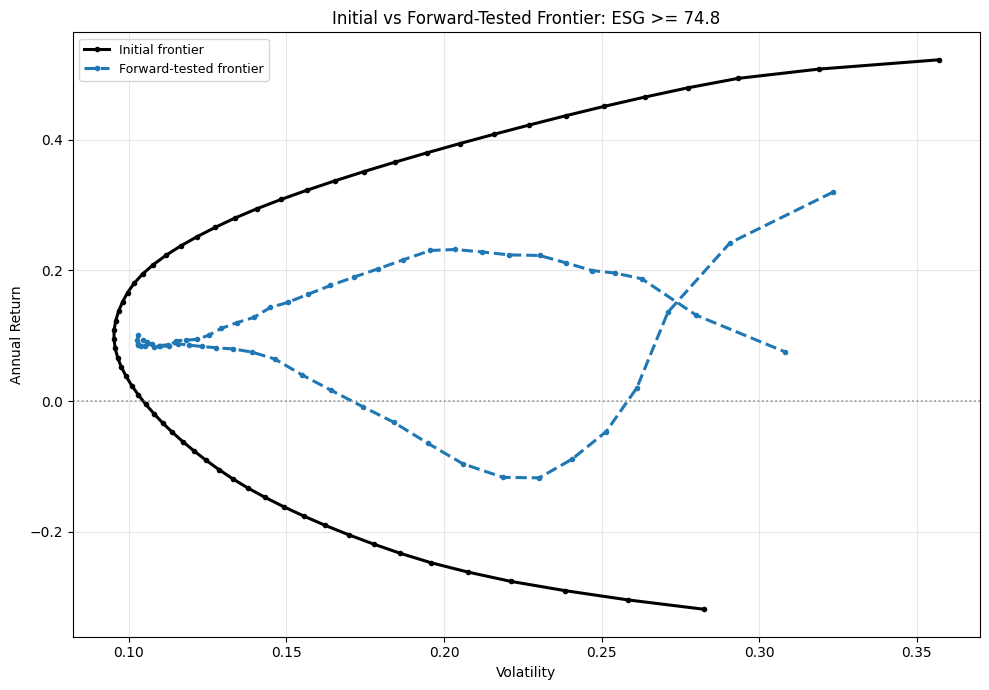

Saved: forward_testing_all_results/initial_vs_forward_esg_74_8.png


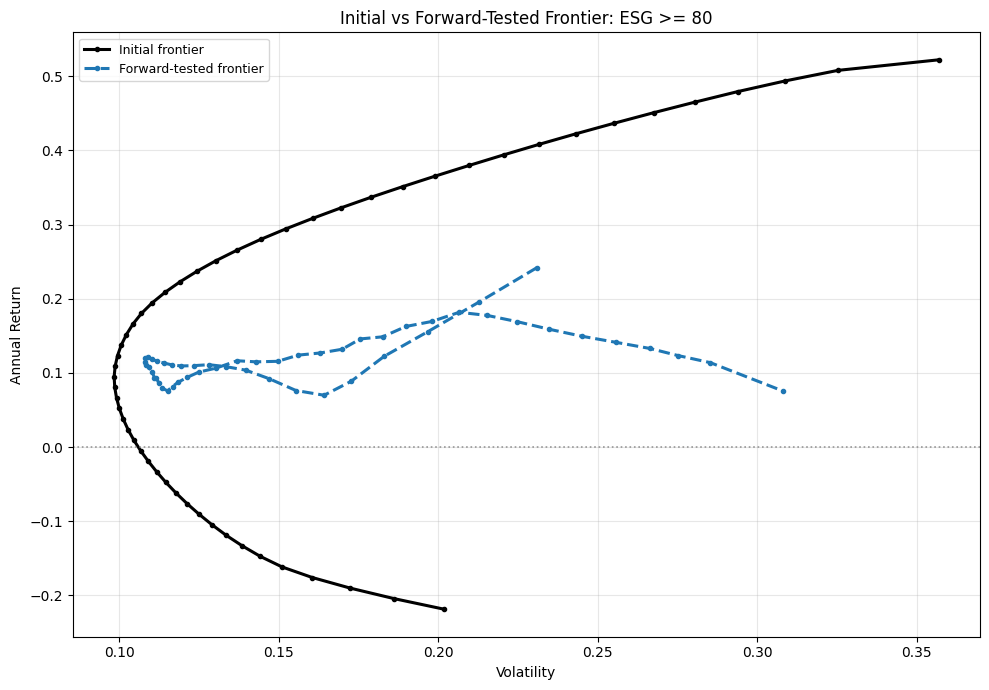

Saved: forward_testing_all_results/initial_vs_forward_esg_80.png


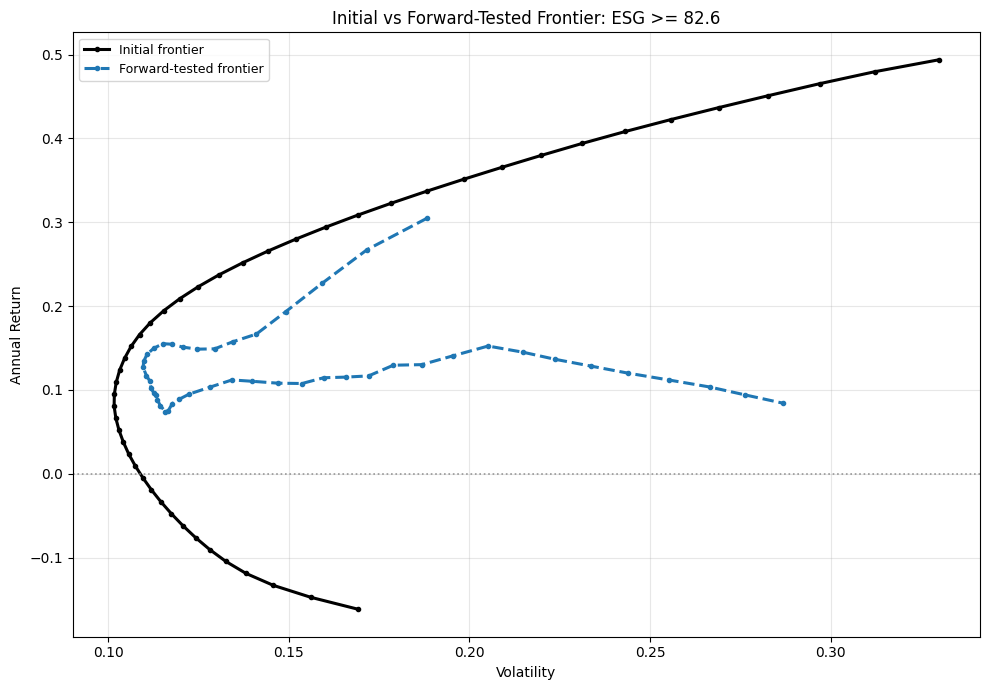

Saved: forward_testing_all_results/initial_vs_forward_esg_82_6.png


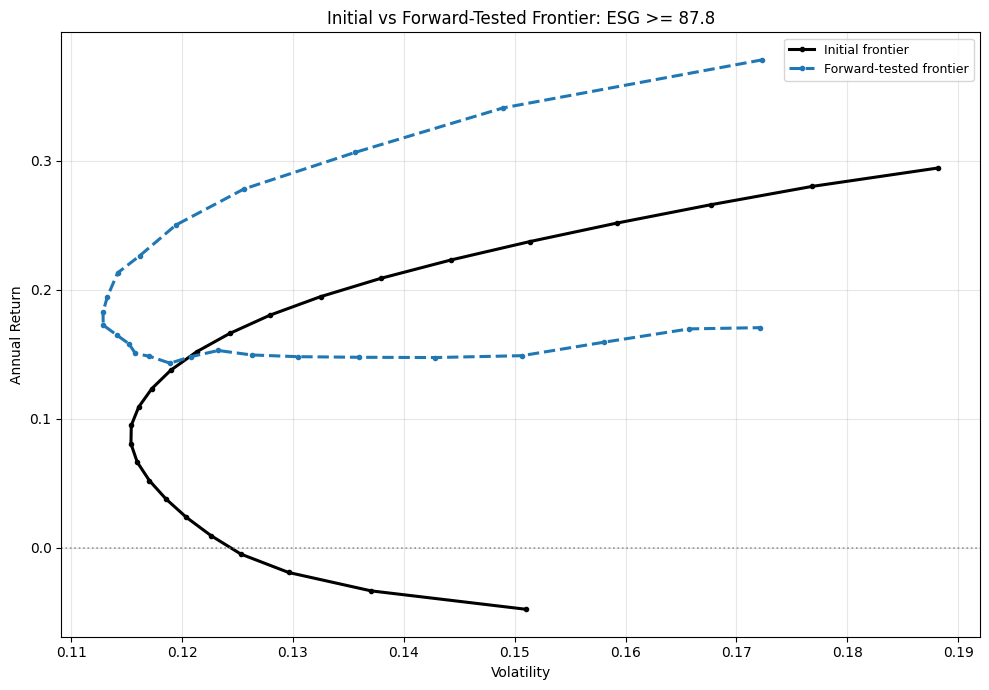

Saved: forward_testing_all_results/initial_vs_forward_esg_87_8.png


In [29]:
# ============================================================
# Individual Initial vs Forward-Tested Frontier Graphs
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

initial_dir = "results_frontiers"
forward_dir = "forward_testing_all_results"

forward_results_path = os.path.join(
    forward_dir,
    "all_frontiers_forward_test_results.csv"
)

forward_df = pd.read_csv(forward_results_path)

selected_frontiers = [
    {
        "name": "No ESG constraint",
        "initial_path": os.path.join(initial_dir, "baseline_frontier.csv"),
        "forward_esg_proxy": 15.0,
        "output_name": "initial_vs_forward_no_esg.png",
    },
    {
        "name": "ESG >= 15",
        "initial_path": os.path.join(initial_dir, "esg_constraint_15_frontier_weights.csv"),
        "forward_esg_proxy": 15.0,
        "output_name": "initial_vs_forward_esg_15.png",
    },
    {
        "name": "ESG >= 43.6",
        "initial_path": os.path.join(initial_dir, "esg_constraint_43.6_frontier_weights.csv"),
        "forward_esg_proxy": 43.6,
        "output_name": "initial_vs_forward_esg_43_6.png",
    },
    {
        "name": "ESG >= 69.6",
        "initial_path": os.path.join(initial_dir, "esg_constraint_69.6_frontier_weights.csv"),
        "forward_esg_proxy": 69.6,
        "output_name": "initial_vs_forward_esg_69_6.png",
    },
    {
        "name": "ESG >= 74.8",
        "initial_path": os.path.join(initial_dir, "esg_constraint_74.8_frontier_weights.csv"),
        "forward_esg_proxy": 74.8,
        "output_name": "initial_vs_forward_esg_74_8.png",
    },
    {
        "name": "ESG >= 80",
        "initial_path": os.path.join(initial_dir, "esg_constraint_80_frontier_weights.csv"),
        "forward_esg_proxy": 80.0,
        "output_name": "initial_vs_forward_esg_80.png",
    },
    {
        "name": "ESG >= 82.6",
        "initial_path": os.path.join(initial_dir, "esg_constraint_82.6_frontier_weights.csv"),
        "forward_esg_proxy": 82.6,
        "output_name": "initial_vs_forward_esg_82_6.png",
    },
    {
        "name": "ESG >= 87.8",
        "initial_path": os.path.join(initial_dir, "esg_constraint_87.8_frontier_weights.csv"),
        "forward_esg_proxy": 87.8,
        "output_name": "initial_vs_forward_esg_87_8.png",
    },
]

for frontier in selected_frontiers:
    initial_df = (
        pd.read_csv(frontier["initial_path"])
        .sort_values("Return")
    )

    realised_df = (
        forward_df[forward_df["ESG_Min"] == frontier["forward_esg_proxy"]]
        .sort_values("In_Sample_Return")
    )

    if realised_df.empty:
        print(f"No forward-tested data found for {frontier['name']}. Skipping.")
        continue

    plt.figure(figsize=(10, 7))

    plt.plot(
        initial_df["Volatility"],
        initial_df["Return"],
        color="black",
        linewidth=2.2,
        linestyle="-",
        marker="o",
        markersize=3,
        label="Initial frontier"
    )

    plt.plot(
        realised_df["Realised_Annual_Volatility"],
        realised_df["Realised_Annual_Return"],
        color="tab:blue",
        linewidth=2.2,
        linestyle="--",
        marker="o",
        markersize=3,
        label="Forward-tested frontier"
    )

    plt.axhline(
        0.0,
        color="grey",
        linestyle=":",
        linewidth=1.2,
        alpha=0.8
    )

    plt.xlabel("Volatility")
    plt.ylabel("Annual Return")
    plt.title(f"Initial vs Forward-Tested Frontier: {frontier['name']}")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)

    plt.tight_layout()

    out_path = os.path.join(forward_dir, frontier["output_name"])
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"Saved: {out_path}")